# **Library Import**
---
---

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

from functions.database_actions_functions import serve_whole_data

import joblib

import tensorflow as tf
import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
from torchmetrics import SymmetricMeanAbsolutePercentageError

In [2]:
def set_global_determinism(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # 2. Force deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True) # Force PyTorch
    
    try:
        tf.config.experimental.enable_op_determinism()
    except AttributeError:
        pass

SEED = 42

set_global_determinism(seed=SEED)

# **Loading Dataset**
---
---

In [2]:
load_dotenv()

list_tables = ['station_details', 'station_sensors', 'weather_readings']
username_postgres = os.getenv('USER_POSTGRES')
pw_postgres = os.getenv('PW_POSTGRES')
db_name = 'data_warehouse_weather'

df = serve_whole_data(username_postgres, pw_postgres, db_name, limit=10000)
df

Existence of DB data_warehouse_weather: True



c:\Users\user\works\DE_studies\openmeteo_ml\functions\database_actions_functions.py:164: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  table_result = pd.io.sql.read_sql_query(f'''


Saved cleaned, read-ML data to c:\Users\user\works\DE_studies\openmeteo_ml\datasets_aggr\weather_readings_mlready.csv


,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W1561901_2023010100,1561901,270693,Waterloo Place,2023-01-01 00:00:00,12.1,89.0,34.1,999.1,0.3,5.1,-0.133068,51.507582
1,W1561901_2023010101,1561901,270693,Waterloo Place,2023-01-01 01:00:00,11.3,94.0,22.9,999.1,0.1,6.2,-0.133068,51.507582
2,W1561901_2023010102,1561901,270693,Waterloo Place,2023-01-01 02:00:00,11.9,85.0,31.1,999.9,0.4,6.6,-0.133068,51.507582
3,W1561901_2023010103,1561901,270693,Waterloo Place,2023-01-01 03:00:00,11.0,80.0,31.4,1000.9,0.0,7.9,-0.133068,51.507582
4,W1561901_2023010104,1561901,270693,Waterloo Place,2023-01-01 04:00:00,10.4,78.0,30.7,1001.9,0.0,8.3,-0.133068,51.507582
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217624,W6955371_2026071905,6955371,225719,Brent,2026-07-19 05:00:00,13.7,70.0,9.2,1019.0,0.0,NaN,-0.247793,51.537799
217625,W6955371_2026071906,6955371,225719,Brent,2026-07-19 06:00:00,13.5,70.0,8.6,1019.1,0.0,NaN,-0.247793,51.537799
217626,W6955371_2026071907,6955371,225719,Brent,2026-07-19 07:00:00,14.1,65.0,9.7,1019.4,0.0,NaN,-0.247793,51.537799
217627,W6955371_2026071908,6955371,225719,Brent,2026-07-19 08:00:00,15.3,60.0,11.0,1019.7,0.0,NaN,-0.247793,51.537799


In [7]:
import datetime

df = df[df['time_reading'] <= datetime.datetime.strptime('2026-07-14 09:00:00', '%Y-%m-%d %H:00:00')] # Getting batched data that is used for the machine learning model
df

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W1561901_2023010100,1561901,270693,Waterloo Place,2023-01-01 00:00:00,12.1,89.0,34.1,999.1,0.3,5.1,-0.133068,51.507582
1,W1561901_2023010101,1561901,270693,Waterloo Place,2023-01-01 01:00:00,11.3,94.0,22.9,999.1,0.1,6.2,-0.133068,51.507582
2,W1561901_2023010102,1561901,270693,Waterloo Place,2023-01-01 02:00:00,11.9,85.0,31.1,999.9,0.4,6.6,-0.133068,51.507582
3,W1561901_2023010103,1561901,270693,Waterloo Place,2023-01-01 03:00:00,11.0,80.0,31.4,1000.9,0.0,7.9,-0.133068,51.507582
4,W1561901_2023010104,1561901,270693,Waterloo Place,2023-01-01 04:00:00,10.4,78.0,30.7,1001.9,0.0,8.3,-0.133068,51.507582
...,...,...,...,...,...,...,...,...,...,...,...,...,...
216784,W6955371_2026071405,6955371,225719,Brent,2026-07-14 05:00:00,15.7,89.0,14.7,1015.8,0.0,NaN,-0.247793,51.537799
216785,W6955371_2026071406,6955371,225719,Brent,2026-07-14 06:00:00,16.4,87.0,18.9,1015.7,0.0,NaN,-0.247793,51.537799
216786,W6955371_2026071407,6955371,225719,Brent,2026-07-14 07:00:00,16.6,87.0,17.5,1016.0,0.0,NaN,-0.247793,51.537799
216787,W6955371_2026071408,6955371,225719,Brent,2026-07-14 08:00:00,17.8,78.0,18.5,1016.2,0.0,NaN,-0.247793,51.537799


# **Exploratory Data Analysis**
---
---

## **1. Data Characteristics**
---

In [4]:
# Data type information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 216789 entries, 0 to 216788
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   weather_id            216789 non-null  str           
 1   sensor_id             216789 non-null  int64         
 2   station_id            216789 non-null  int64         
 3   station_name          216789 non-null  str           
 4   time_reading          216789 non-null  datetime64[us]
 5   temperature_2m        216789 non-null  float64       
 6   relative_humidity_2m  216789 non-null  float64       
 7   wind_speed_10m        216789 non-null  float64       
 8   surface_pressure      216789 non-null  float64       
 9   rain                  216789 non-null  float64       
 10  pm25                  158081 non-null  float64       
 11  longitude             216789 non-null  float64       
 12  latitude              216789 non-null  float64       
dtypes: datetim

In [5]:
# Statistical Characteristics
df.describe(include='all')

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
count,216789,2.167890e+05,216789.000000,216789,216789,216789.000000,216789.000000,216789.000000,216789.000000,216789.000000,158081.000000,216789.000000,216789.000000
unique,216789,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,W1561901_2023010100,NaN,NaN,Waterloo Place,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,30970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.880743e+06,176922.632057,NaN,2024-10-07 04:34:17.135740,11.911065,77.254003,13.428587,1010.652149,0.085499,8.877514,-0.092626,51.503411
min,NaN,2.350000e+02,152.000000,NaN,2023-01-01 00:00:00,-5.300000,9.000000,0.000000,946.900000,0.000000,-4.000000,-0.247793,51.449674
25%,NaN,2.889000e+04,159.000000,NaN,2023-11-19 14:00:00,7.500000,68.000000,8.300000,1004.000000,0.000000,4.810000,-0.175269,51.486957
50%,NaN,1.304734e+06,225751.000000,NaN,2024-10-07 05:00:00,11.400000,81.000000,12.300000,1011.800000,0.000000,7.000000,-0.131931,51.502988
75%,NaN,2.009625e+06,270693.000000,NaN,2025-08-25 19:00:00,16.000000,90.000000,17.500000,1018.600000,0.000000,10.700000,-0.018022,51.537799
max,NaN,6.955371e+06,290183.000000,NaN,2026-07-14 09:00:00,36.300000,100.000000,52.500000,1045.100000,15.500000,744.000000,0.095111,51.544210


In [6]:
# Missing values & Duplicates
print('Missing Values:')
display(df.isnull().sum())

print(f'\nDuplicated Values: {df.duplicated().sum()}')

Missing Values:


weather_id                  0
sensor_id                   0
station_id                  0
station_name                0
time_reading                0
temperature_2m              0
relative_humidity_2m        0
wind_speed_10m              0
surface_pressure            0
rain                        0
pm25                    58708
longitude                   0
latitude                    0
dtype: int64


Duplicated Values: 0


## **2. Data Distribution**
---

### 2.1. Categorical Data distribution
---

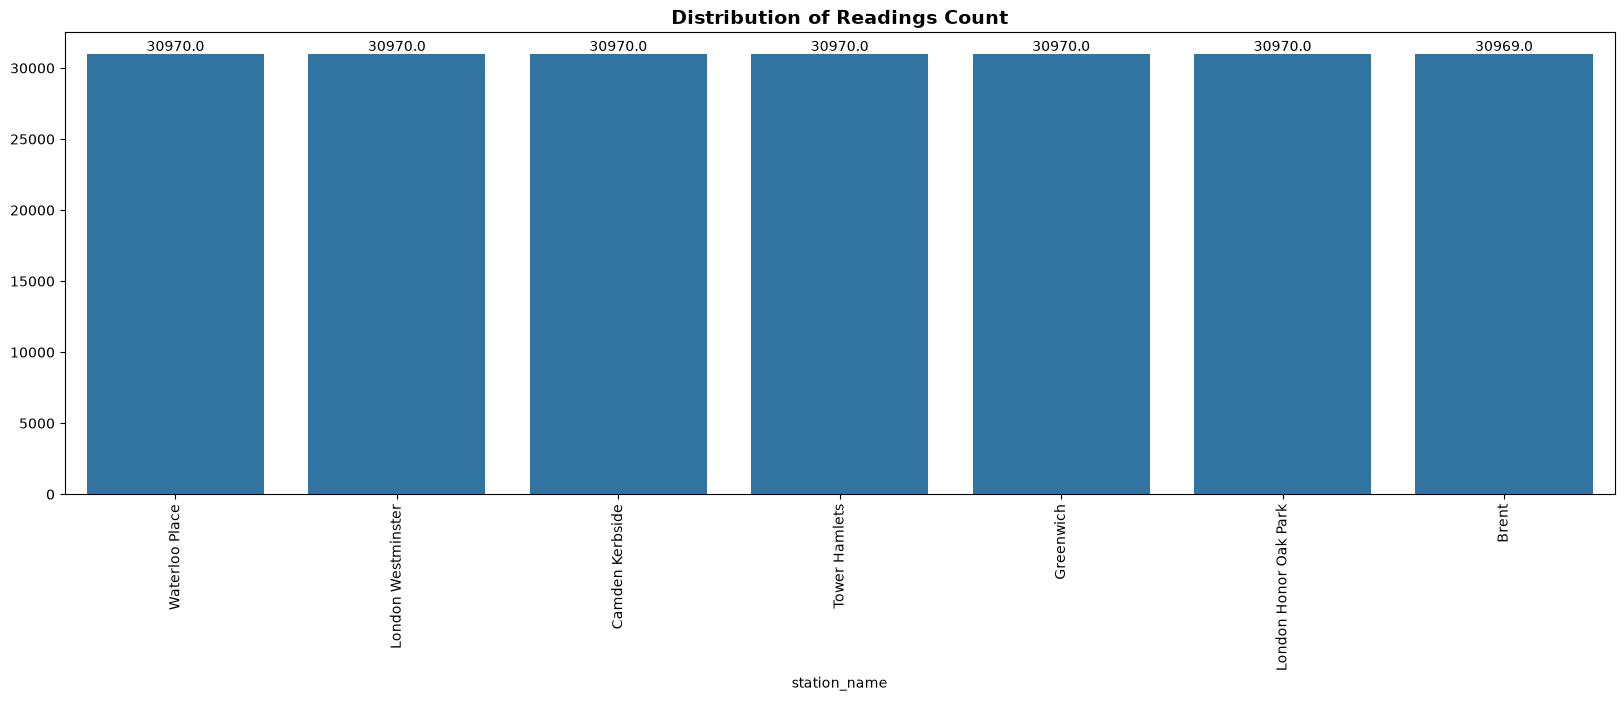

In [5]:
plt.figure(figsize=(20, 6))
count = df['station_name'].value_counts()
ax = sns.barplot(x=count.index, y=count.values)
for val in ax.containers:
    label = [v.get_height() for v in val]
    ax.bar_label(val, labels=label, label_type='edge')
plt.xticks(rotation=90)
plt.title('Distribution of Readings Count', fontsize=14, fontweight='bold')
plt.show()

### 2.2. Numerical Data distribution
---

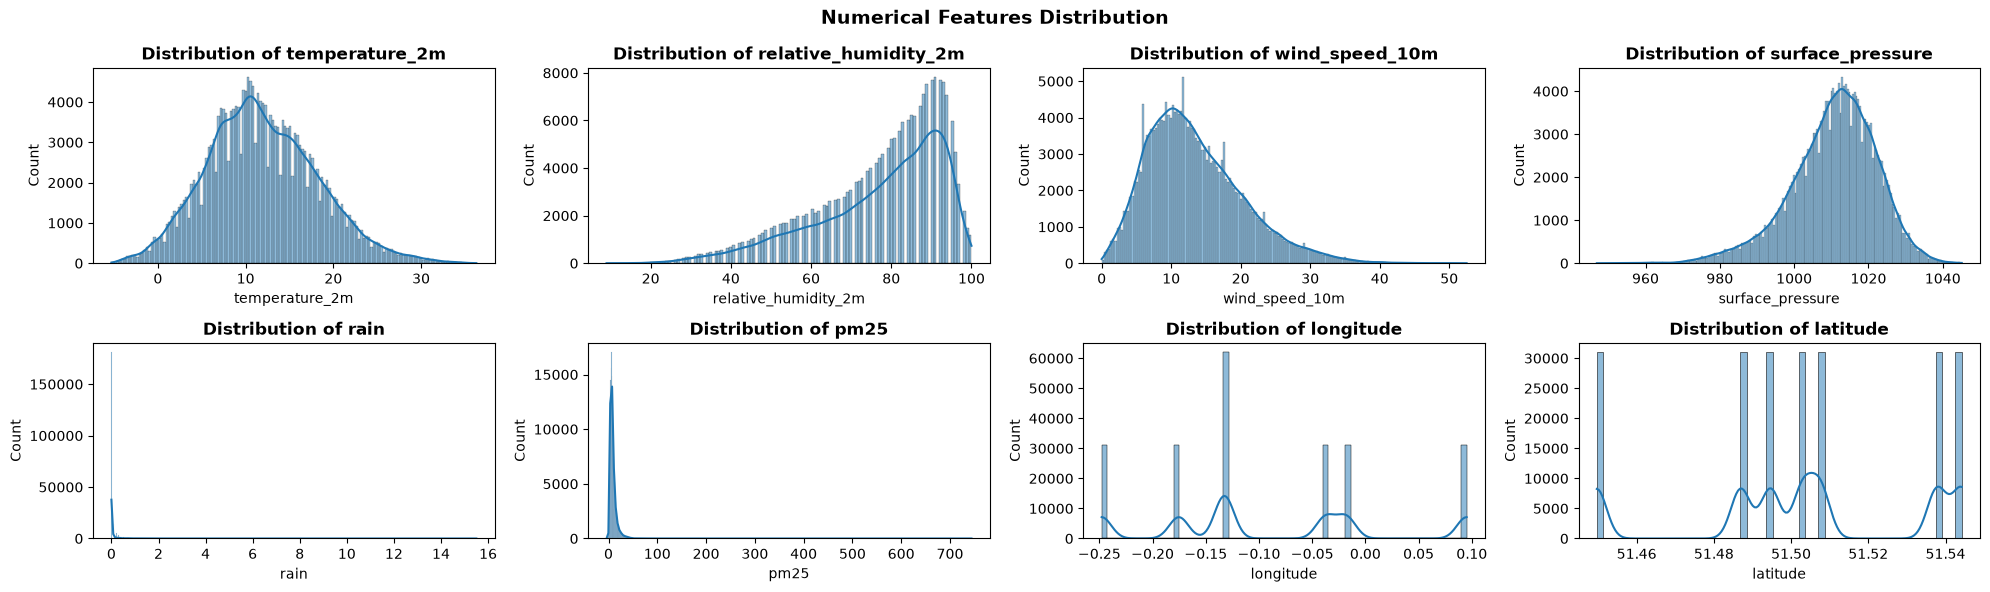

In [8]:
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]

plt.figure(figsize=(20, 6))
for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **3. Outlier Distribution**
---

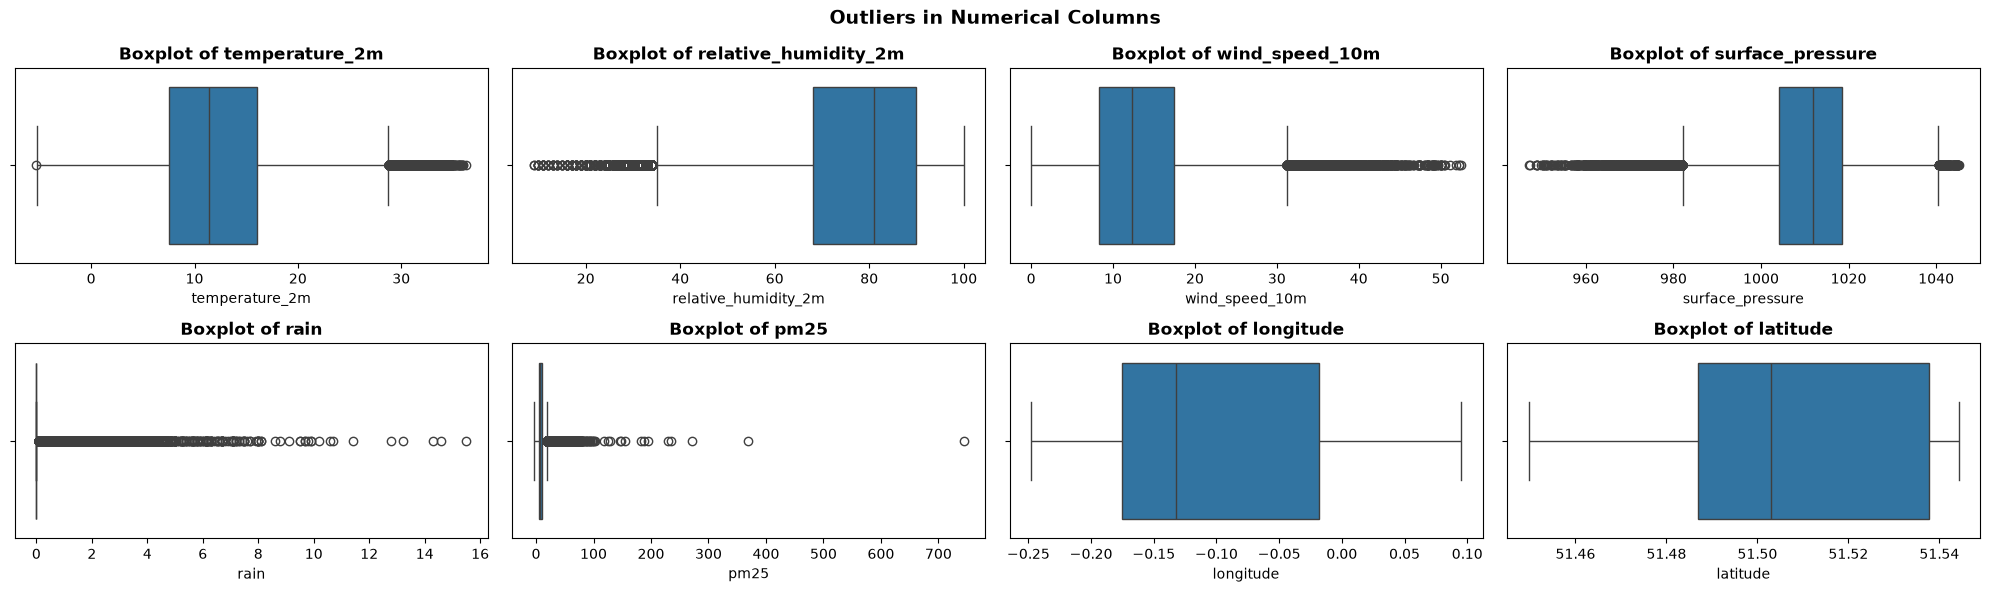

In [9]:
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]

plt.figure(figsize=(20, 6))
for i, col in enumerate(cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
plt.suptitle('Outliers in Numerical Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **4. Correlation Analysis**
---

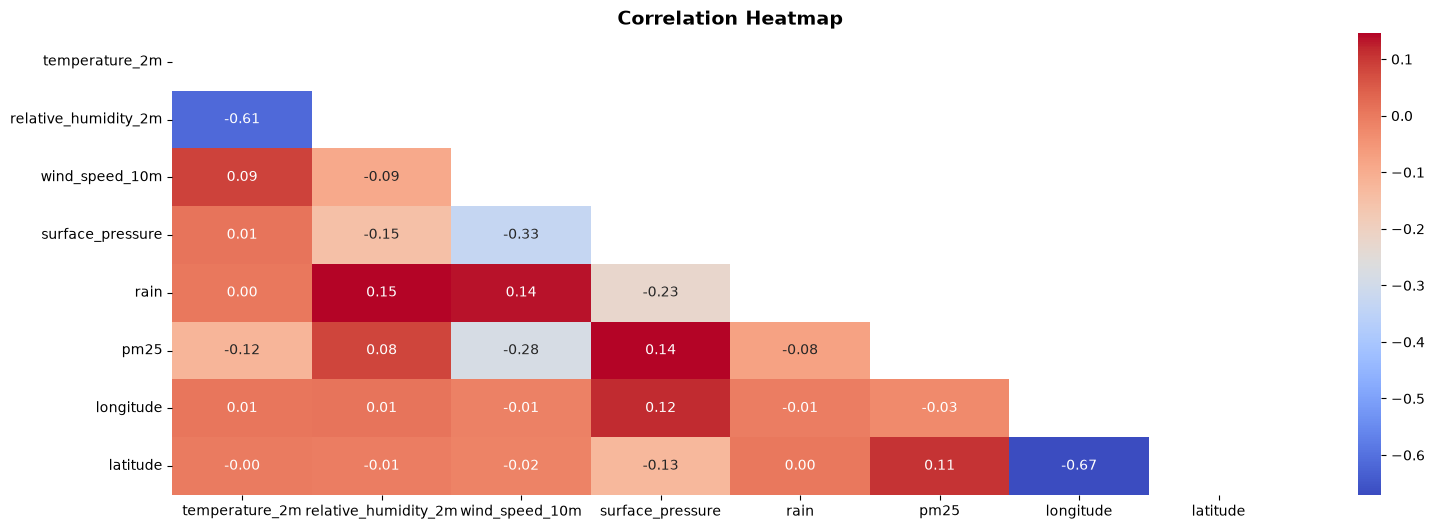

In [10]:
# Regular Correlation
forbid = ['sensor_id', 'station_id']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]
corr = df[cols].corr()

plt.figure(figsize=(18, 6))
mask = np.triu(np.ones_like(corr, dtype=float))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [11]:
# Cross Correlation
# Note: shift by 1 --> gets a record's previous value, shift by 2 --> gets a record's next value
df_try = df.copy()
range_lags = range(0, 20)
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df_try.select_dtypes(include='number').columns if col not in forbid]

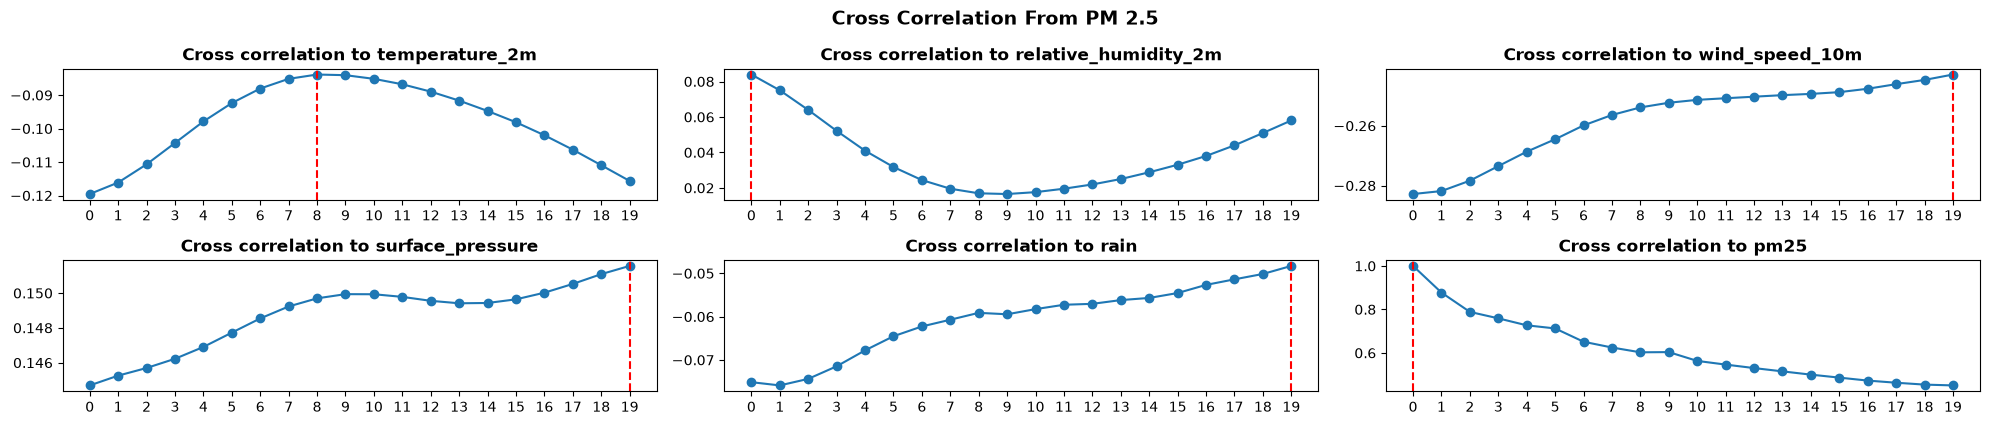

In [12]:
correlations = {}
max_corrs = {}
for col in cols:
    correlations[col] = []
    for lag in range_lags: # loops through all lags
        corr_curr = df_try['pm25'].corr(df_try[col].shift(lag)) # gets the correlation between PM2.5 readings to the previous x hours
        correlations[col].append(corr_curr) # appends the correlation
    idx_max = correlations[col].index(max(correlations[col])) # extracts index/lag wwith highest correlation
    max_corrs[col] = range_lags[idx_max]

plt.figure(figsize=(20, 6))
for i, col in enumerate(cols):
    plt.subplot(3, 3, i+1)
    plt.plot(range_lags, correlations[col], marker='o', linestyle='-')
    plt.axvline(x=max_corrs[col], color='red', linestyle='--', label=f'Peak lag: {max_corrs[col]} hours')
    plt.title(f'Cross correlation to {col}', fontsize=12, fontweight='bold')
    plt.xticks(list(range_lags))
plt.suptitle('Cross Correlation From PM 2.5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **5. Weather and PM 2.5 Levels Overtime**
---

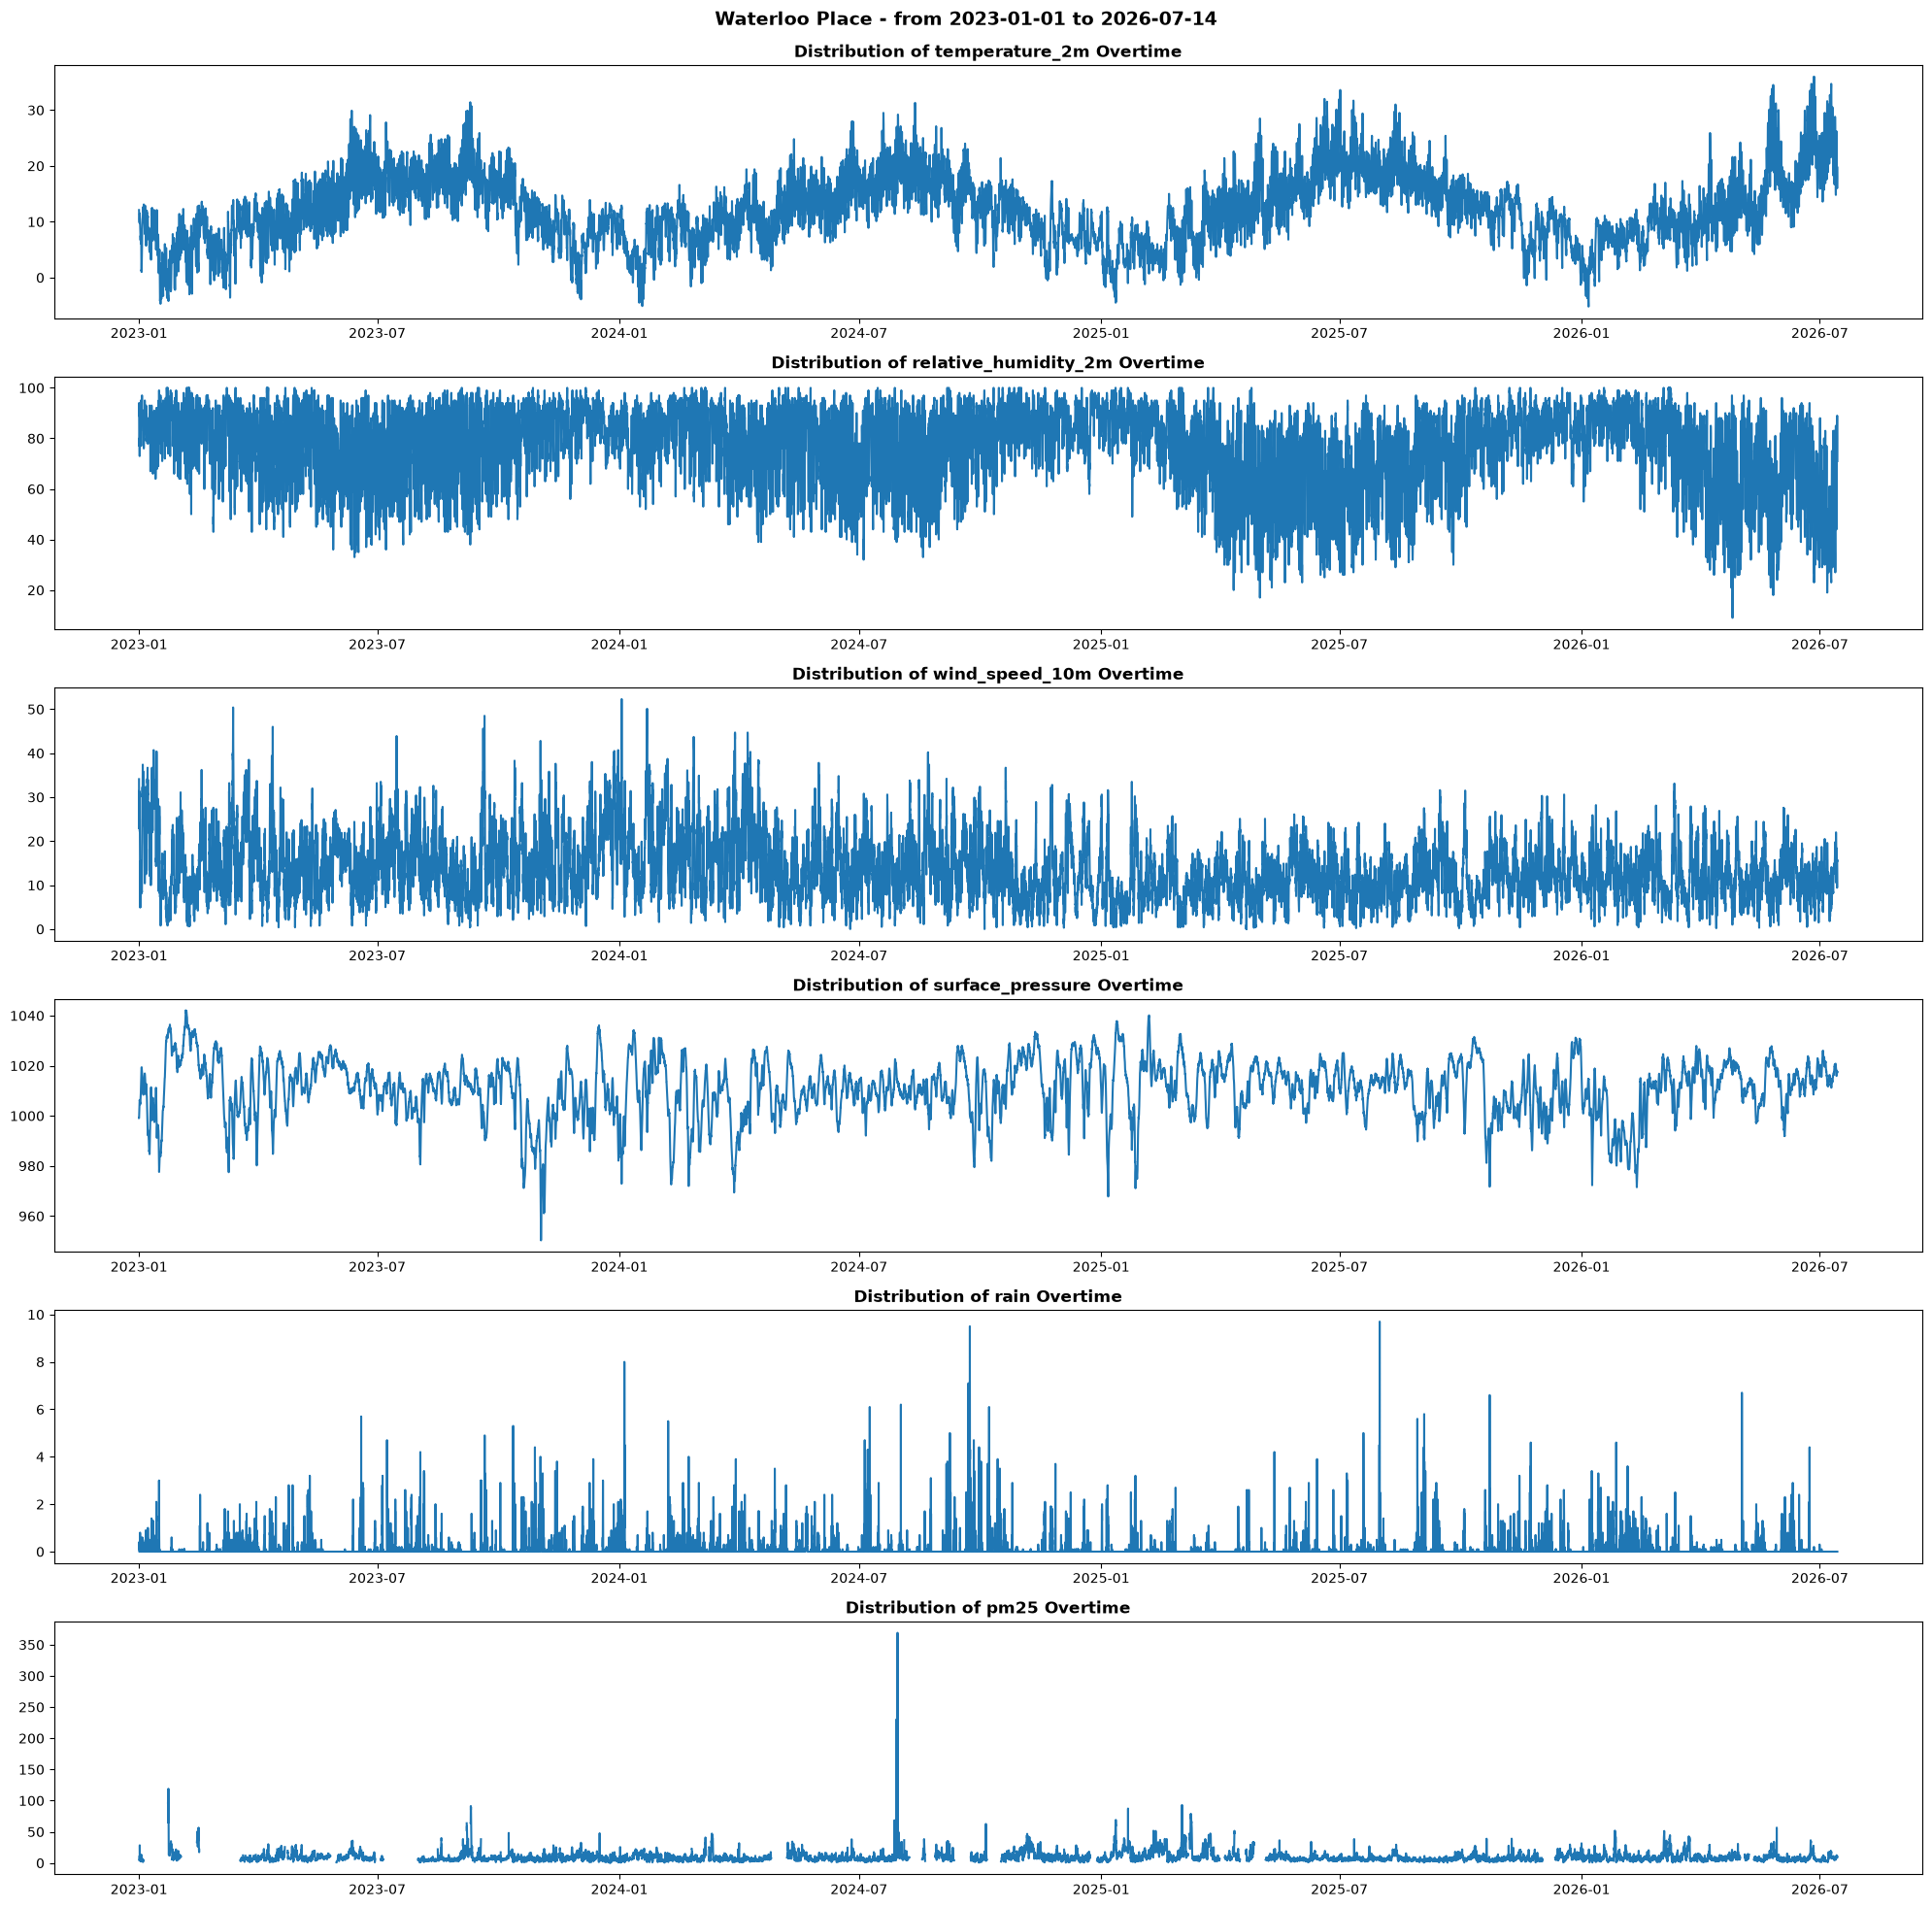

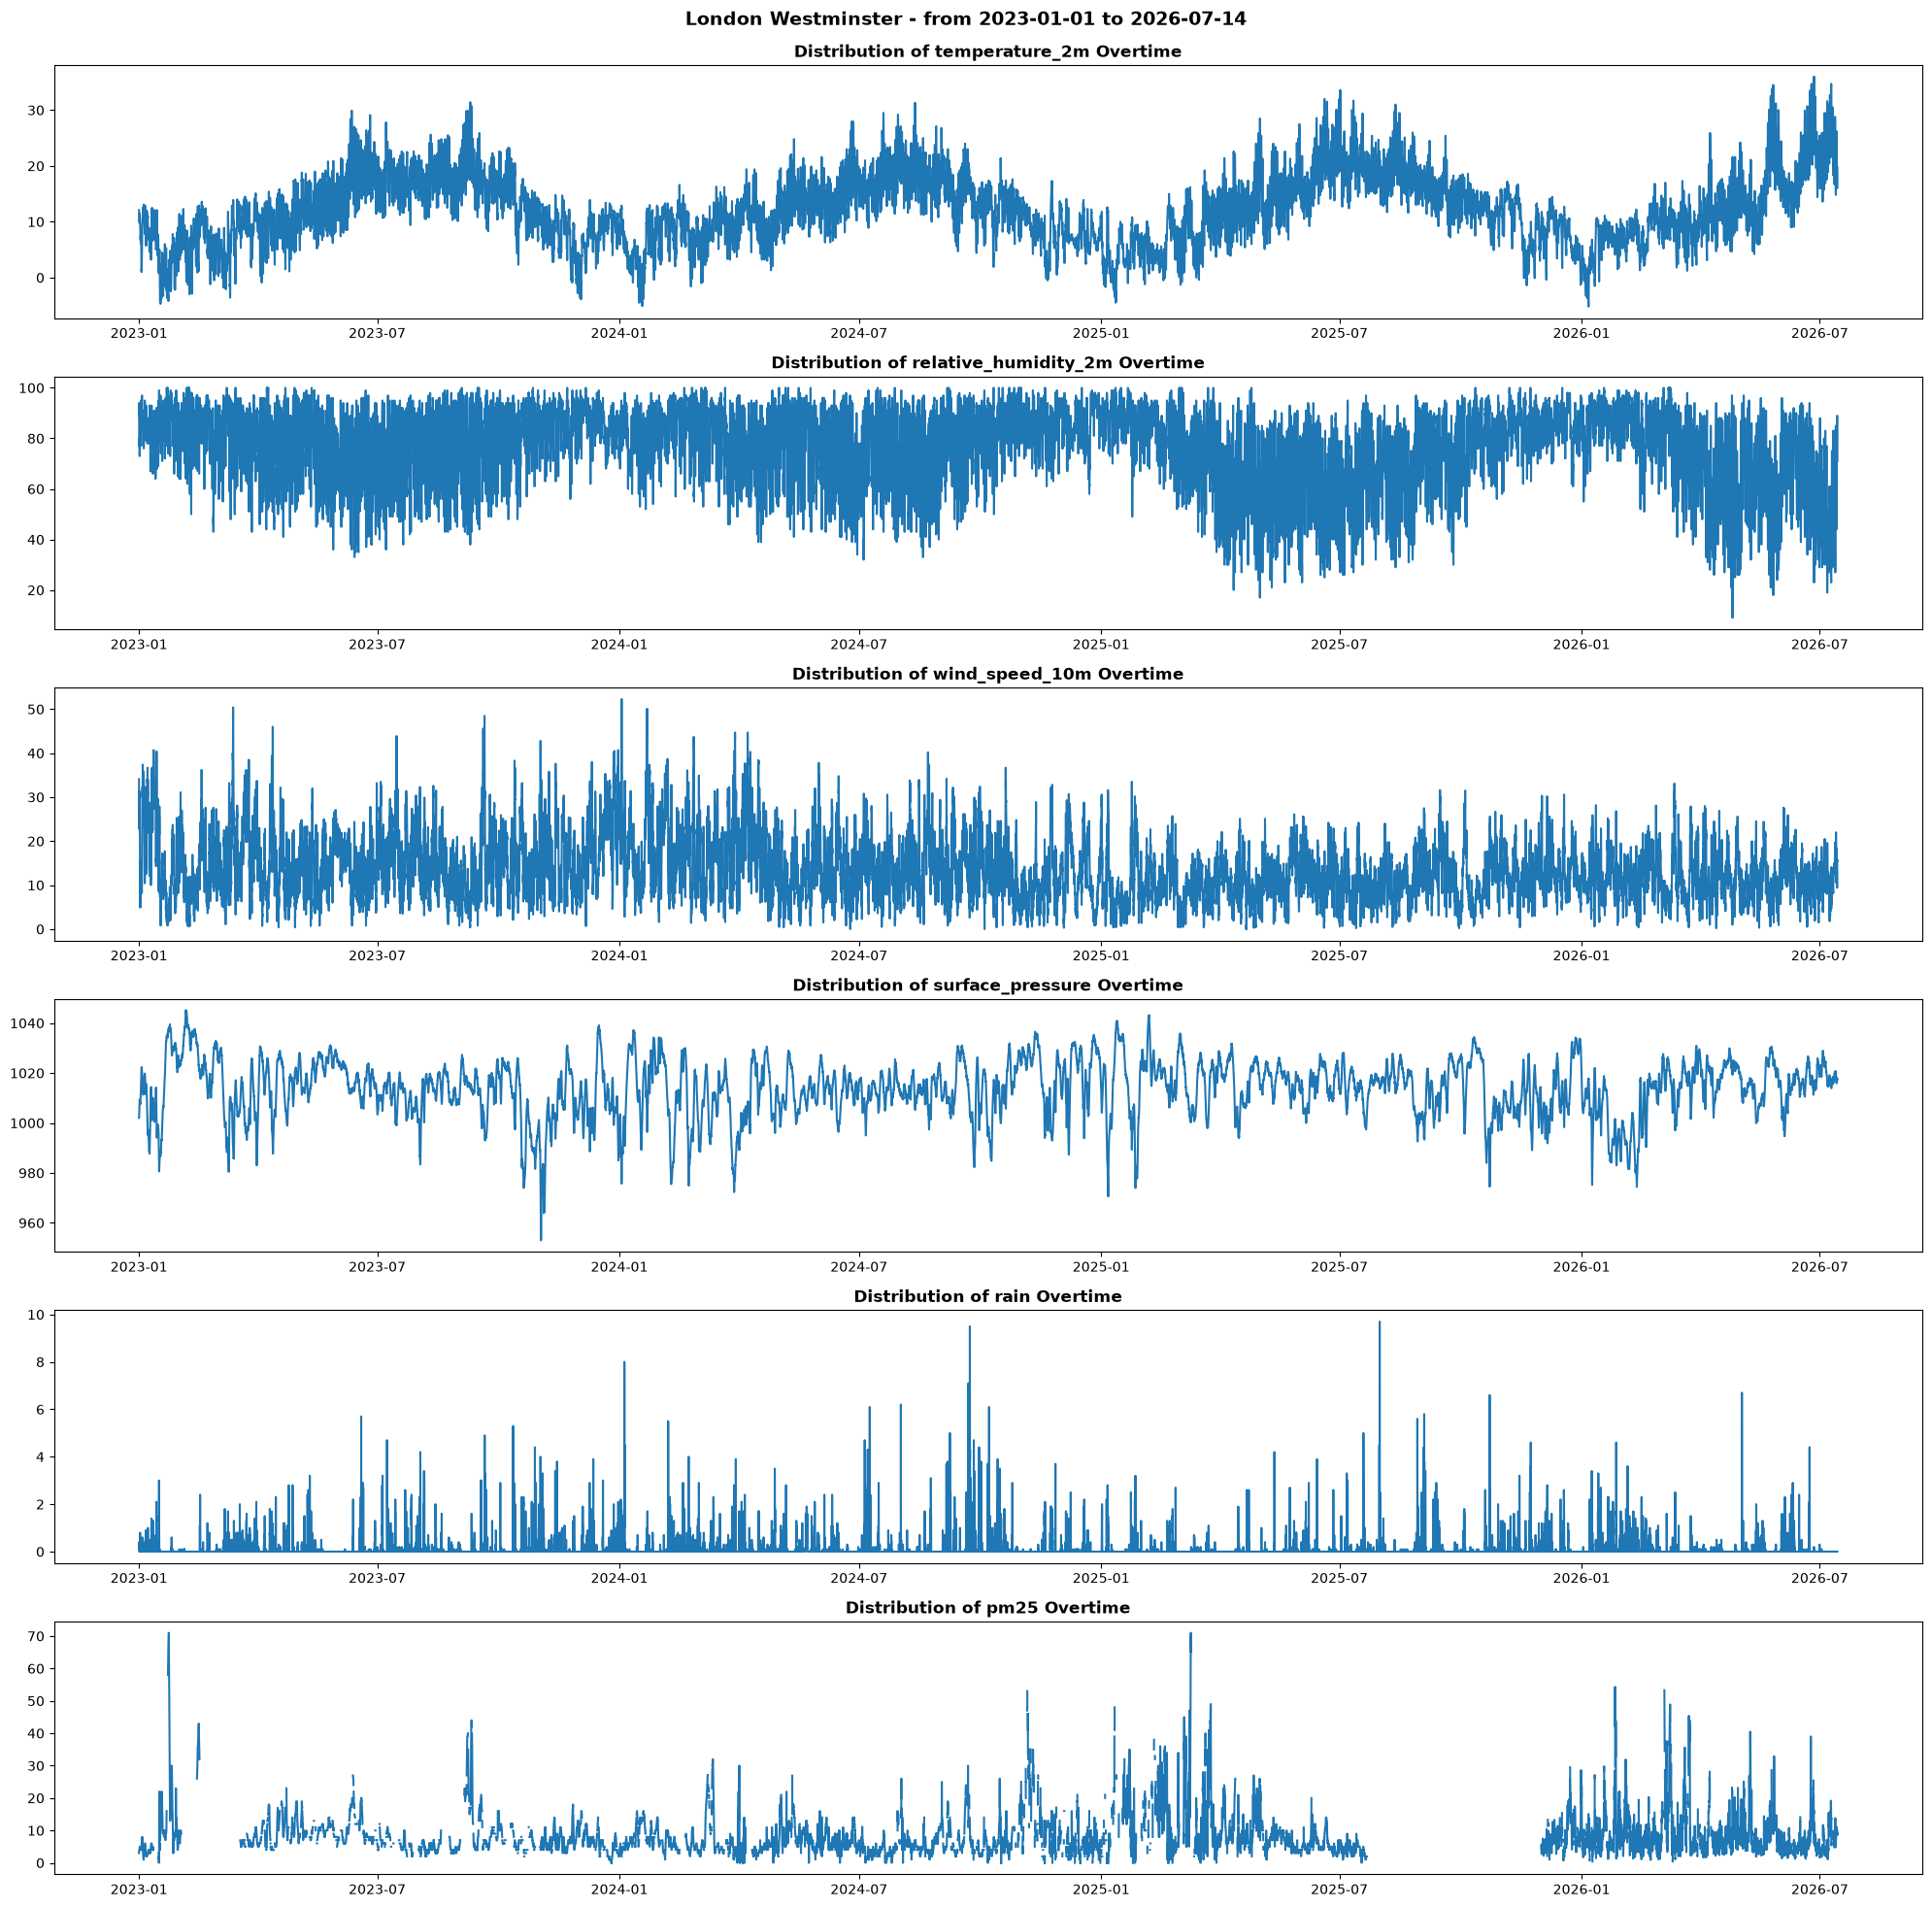

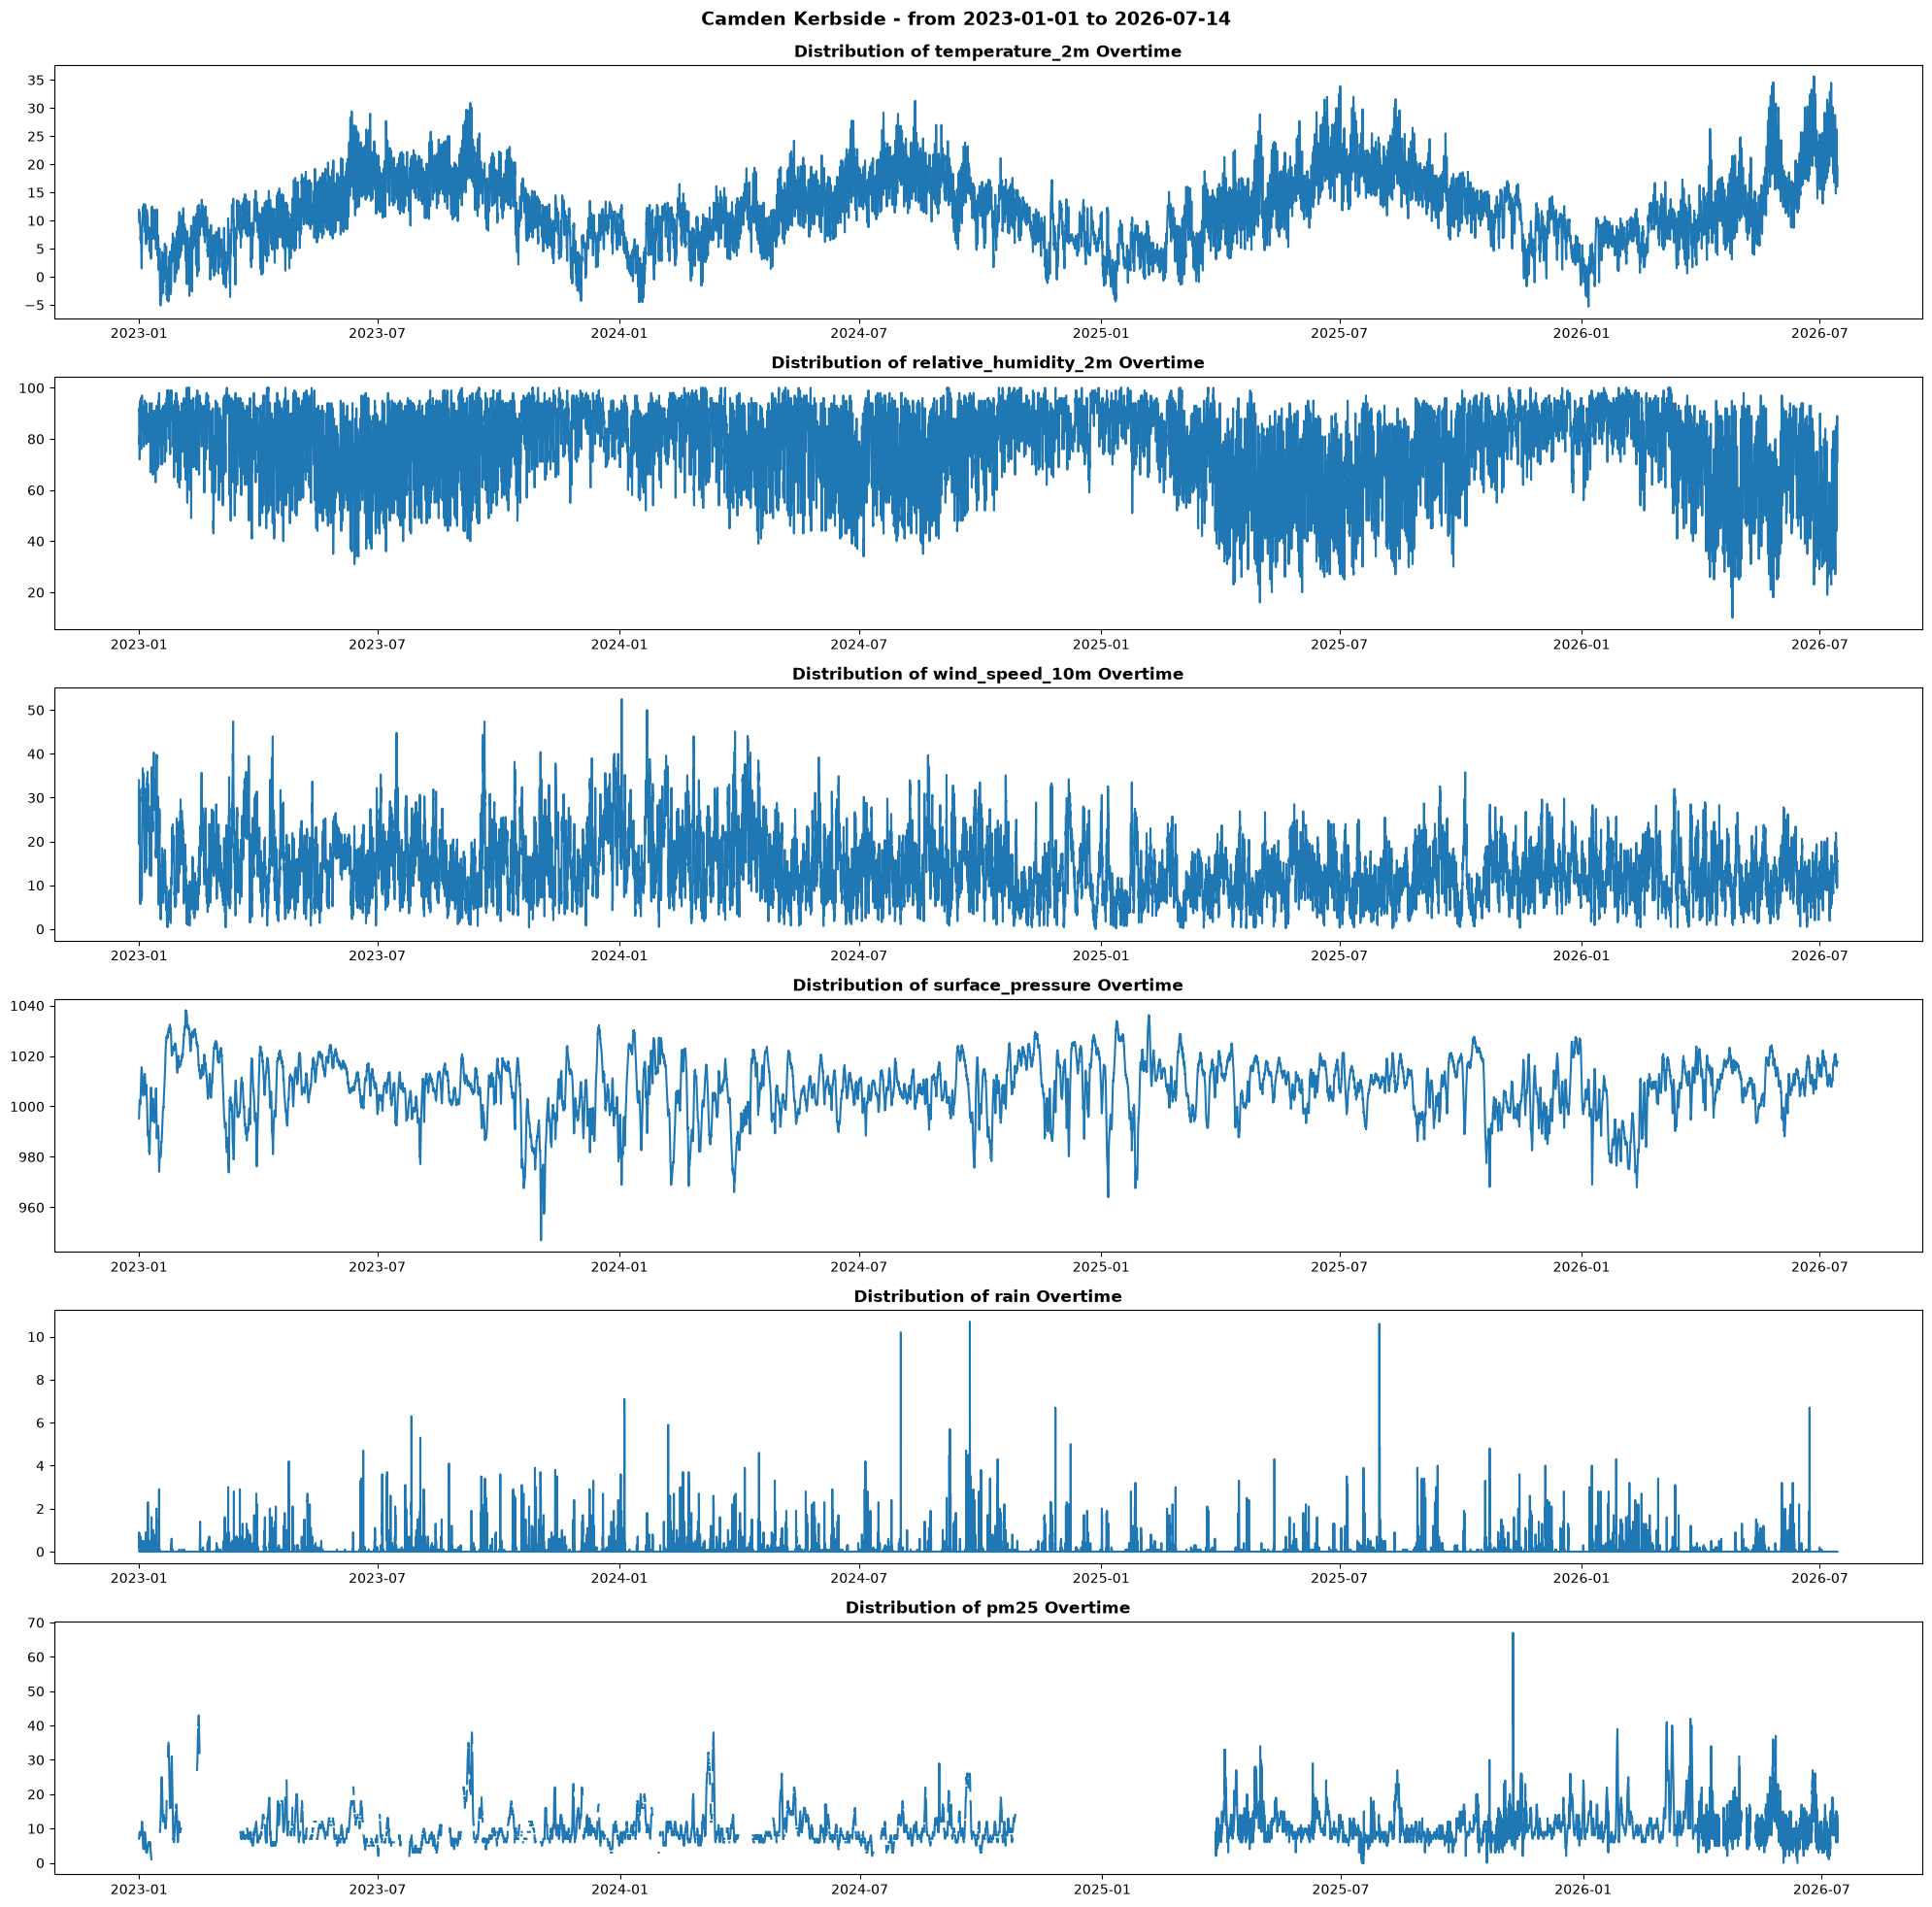

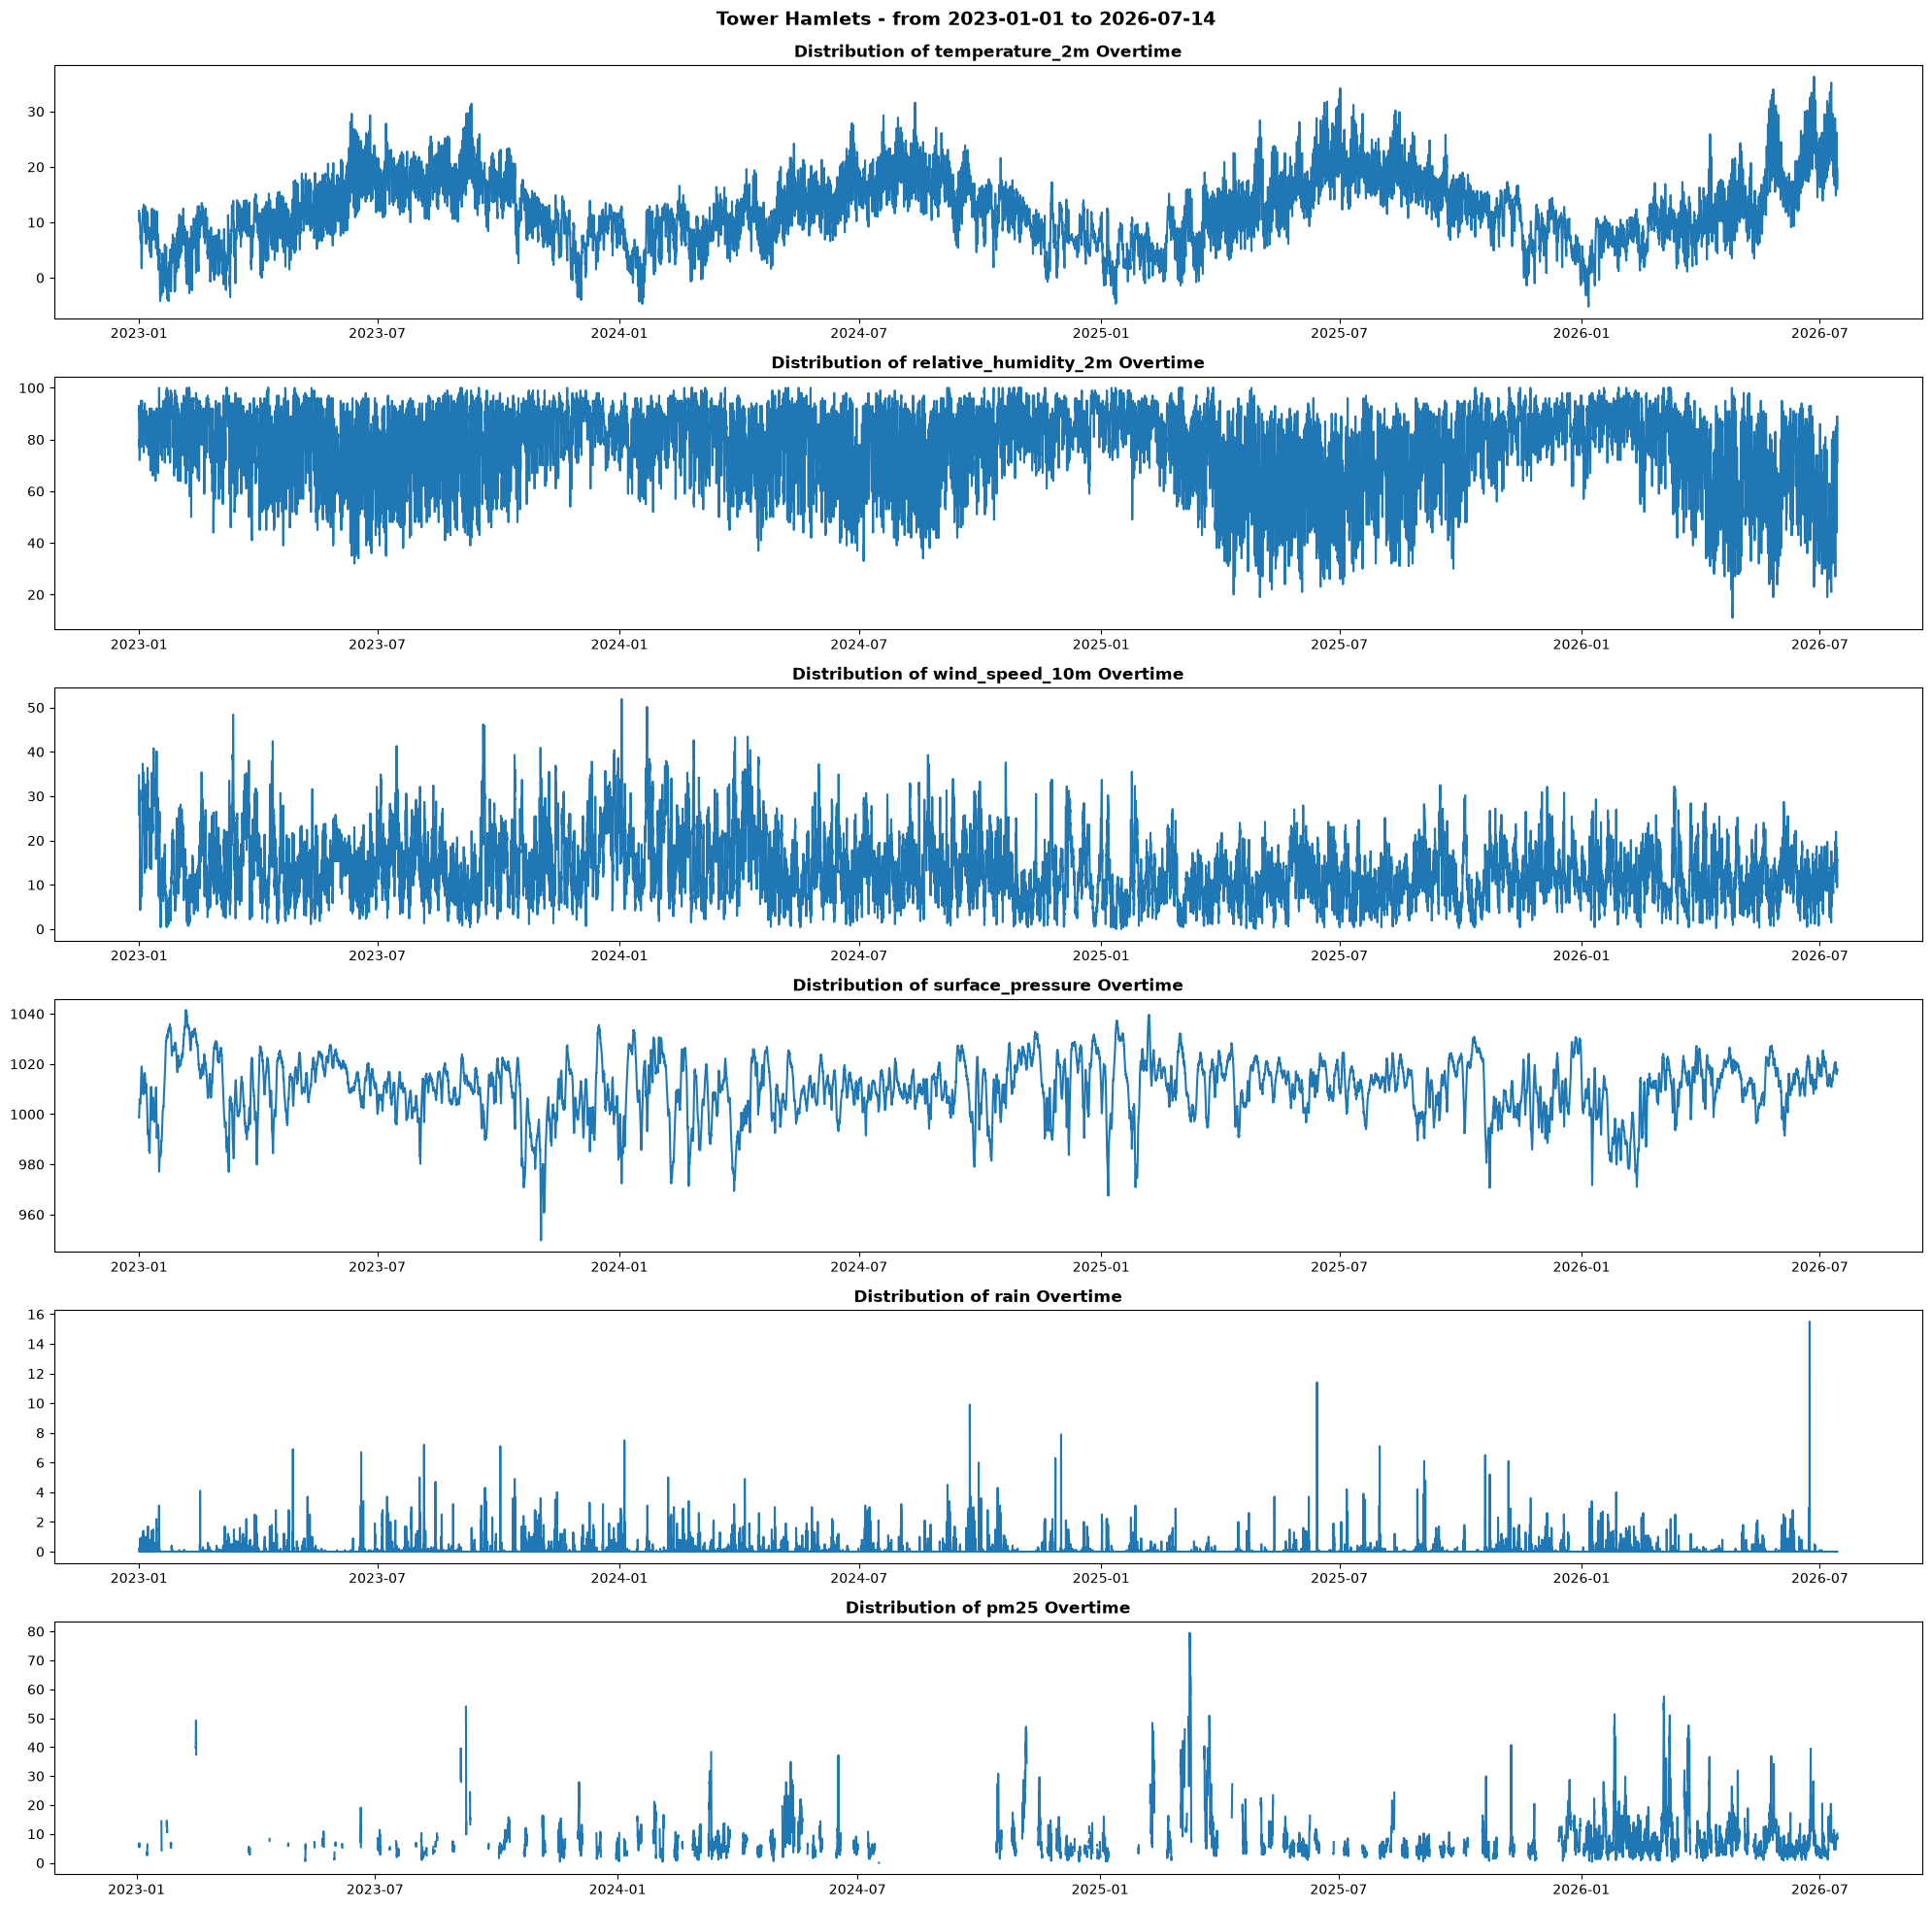

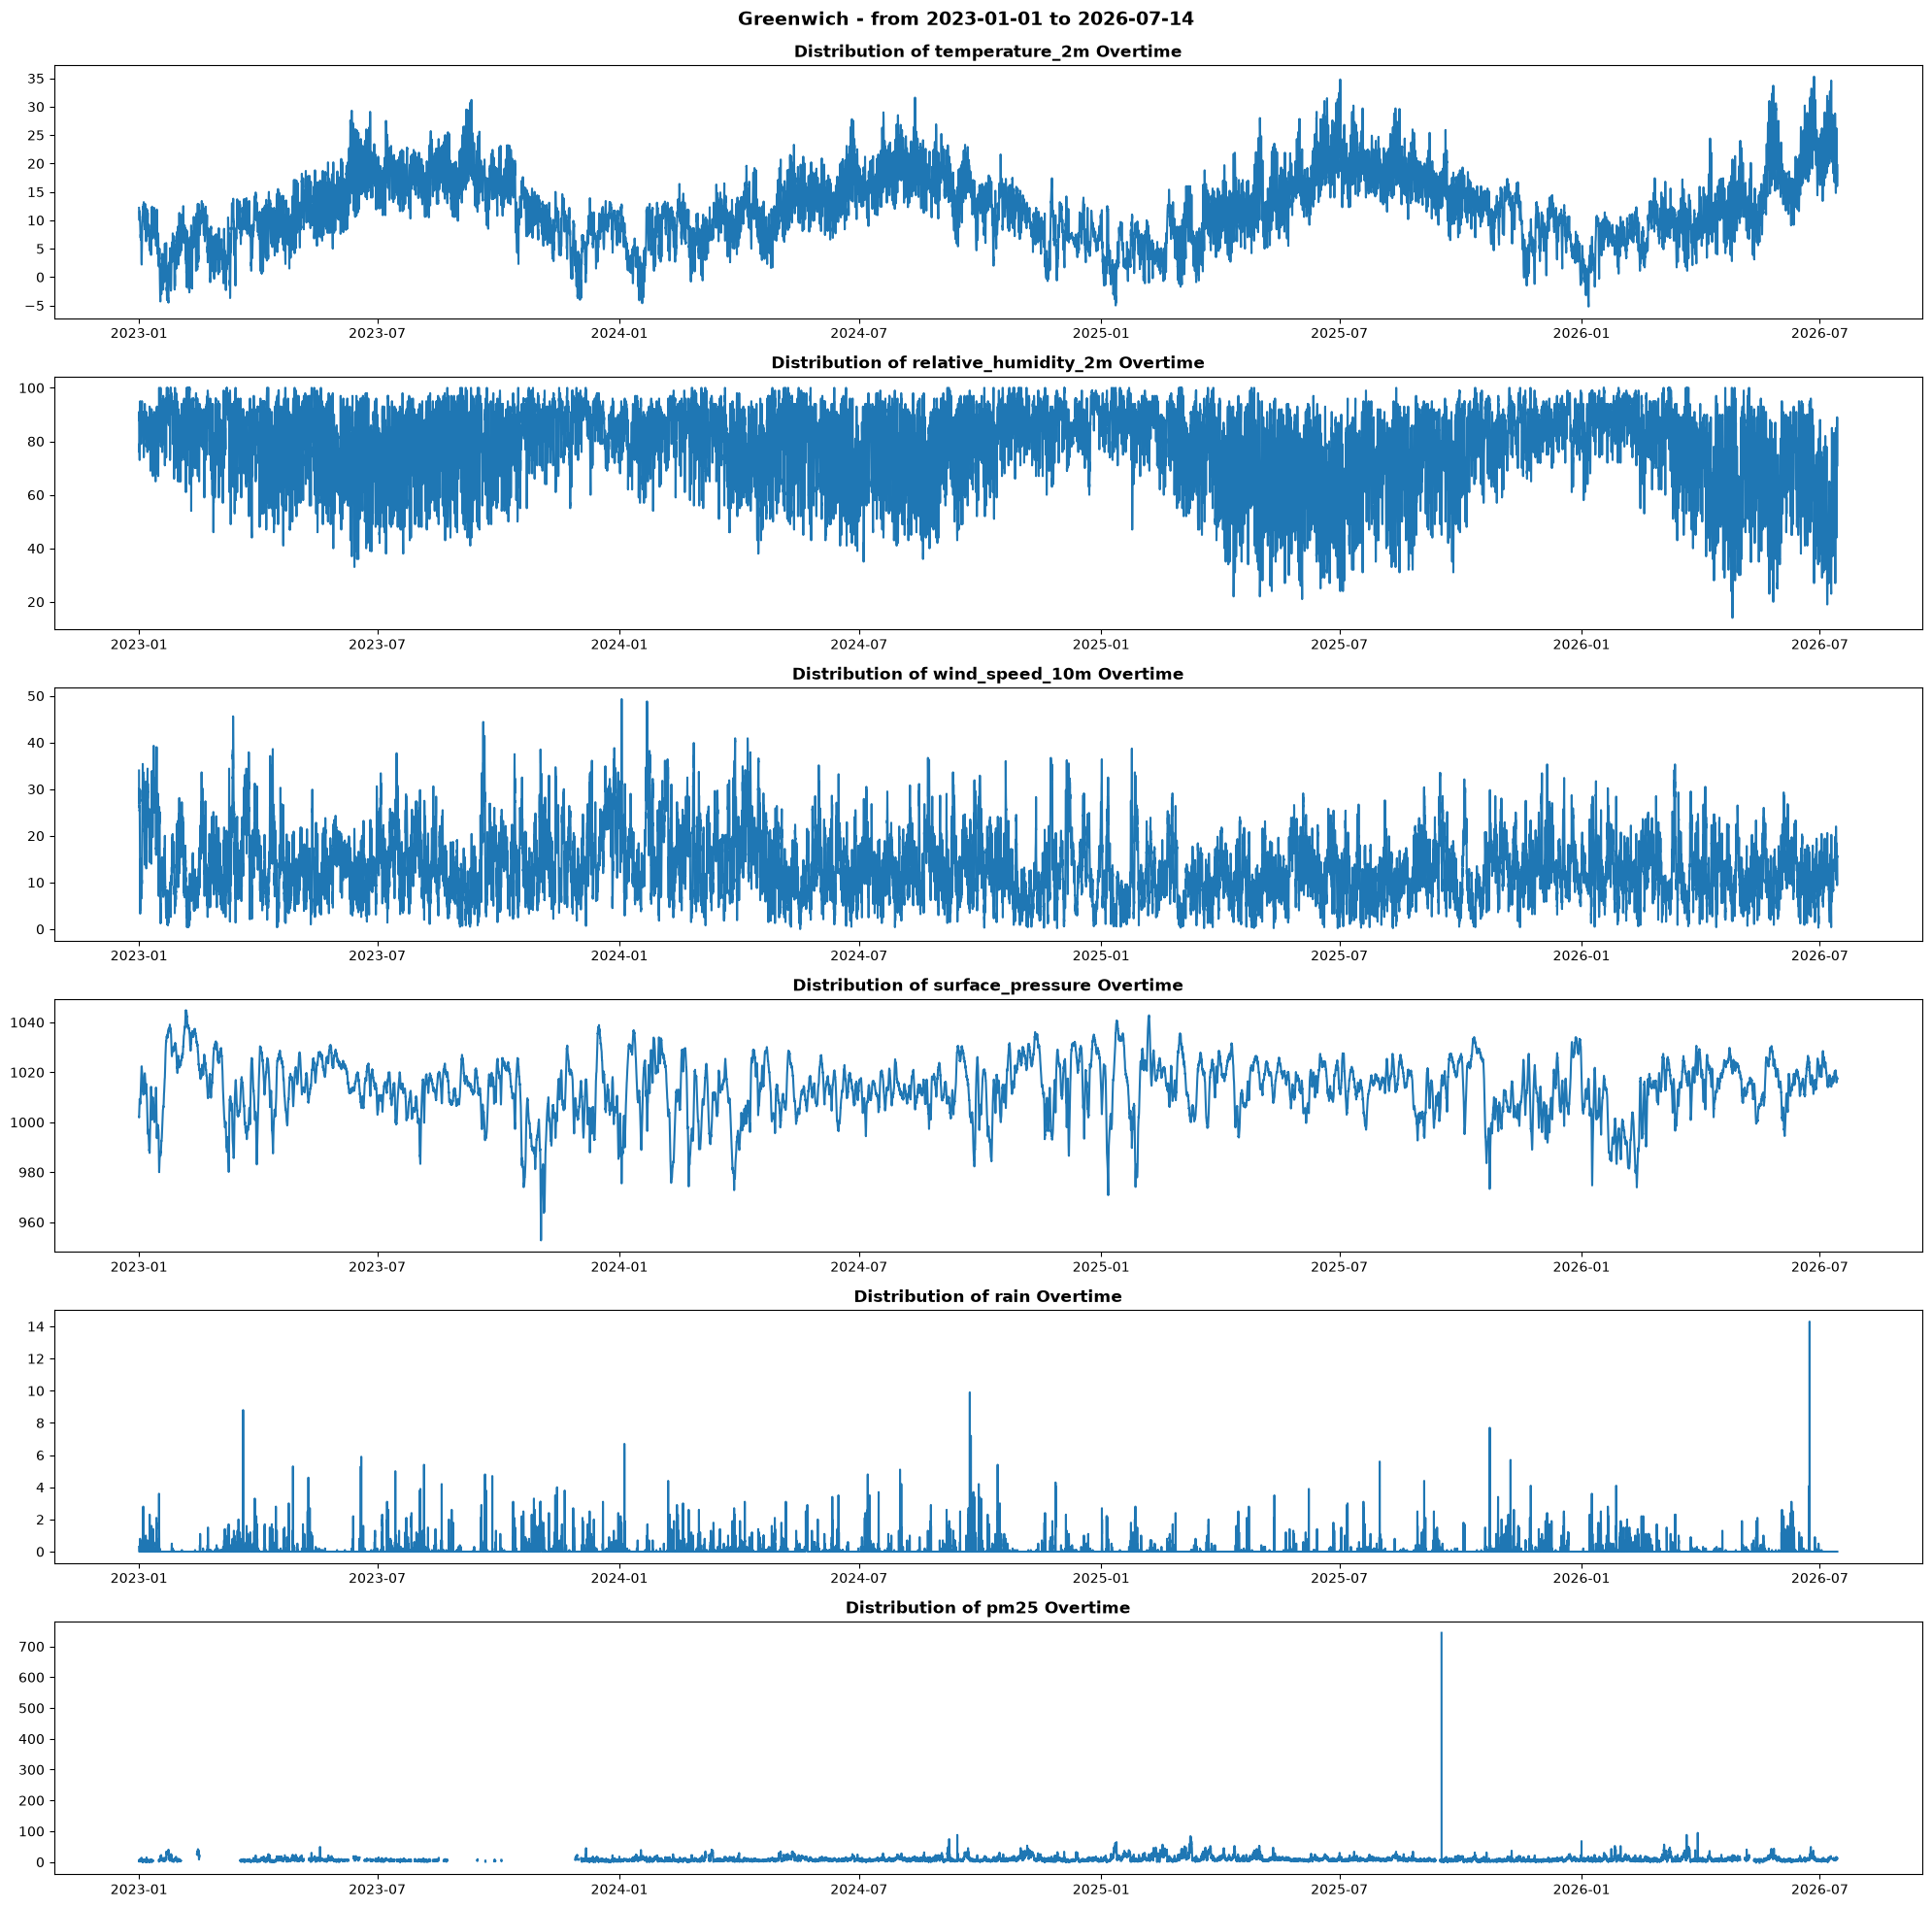

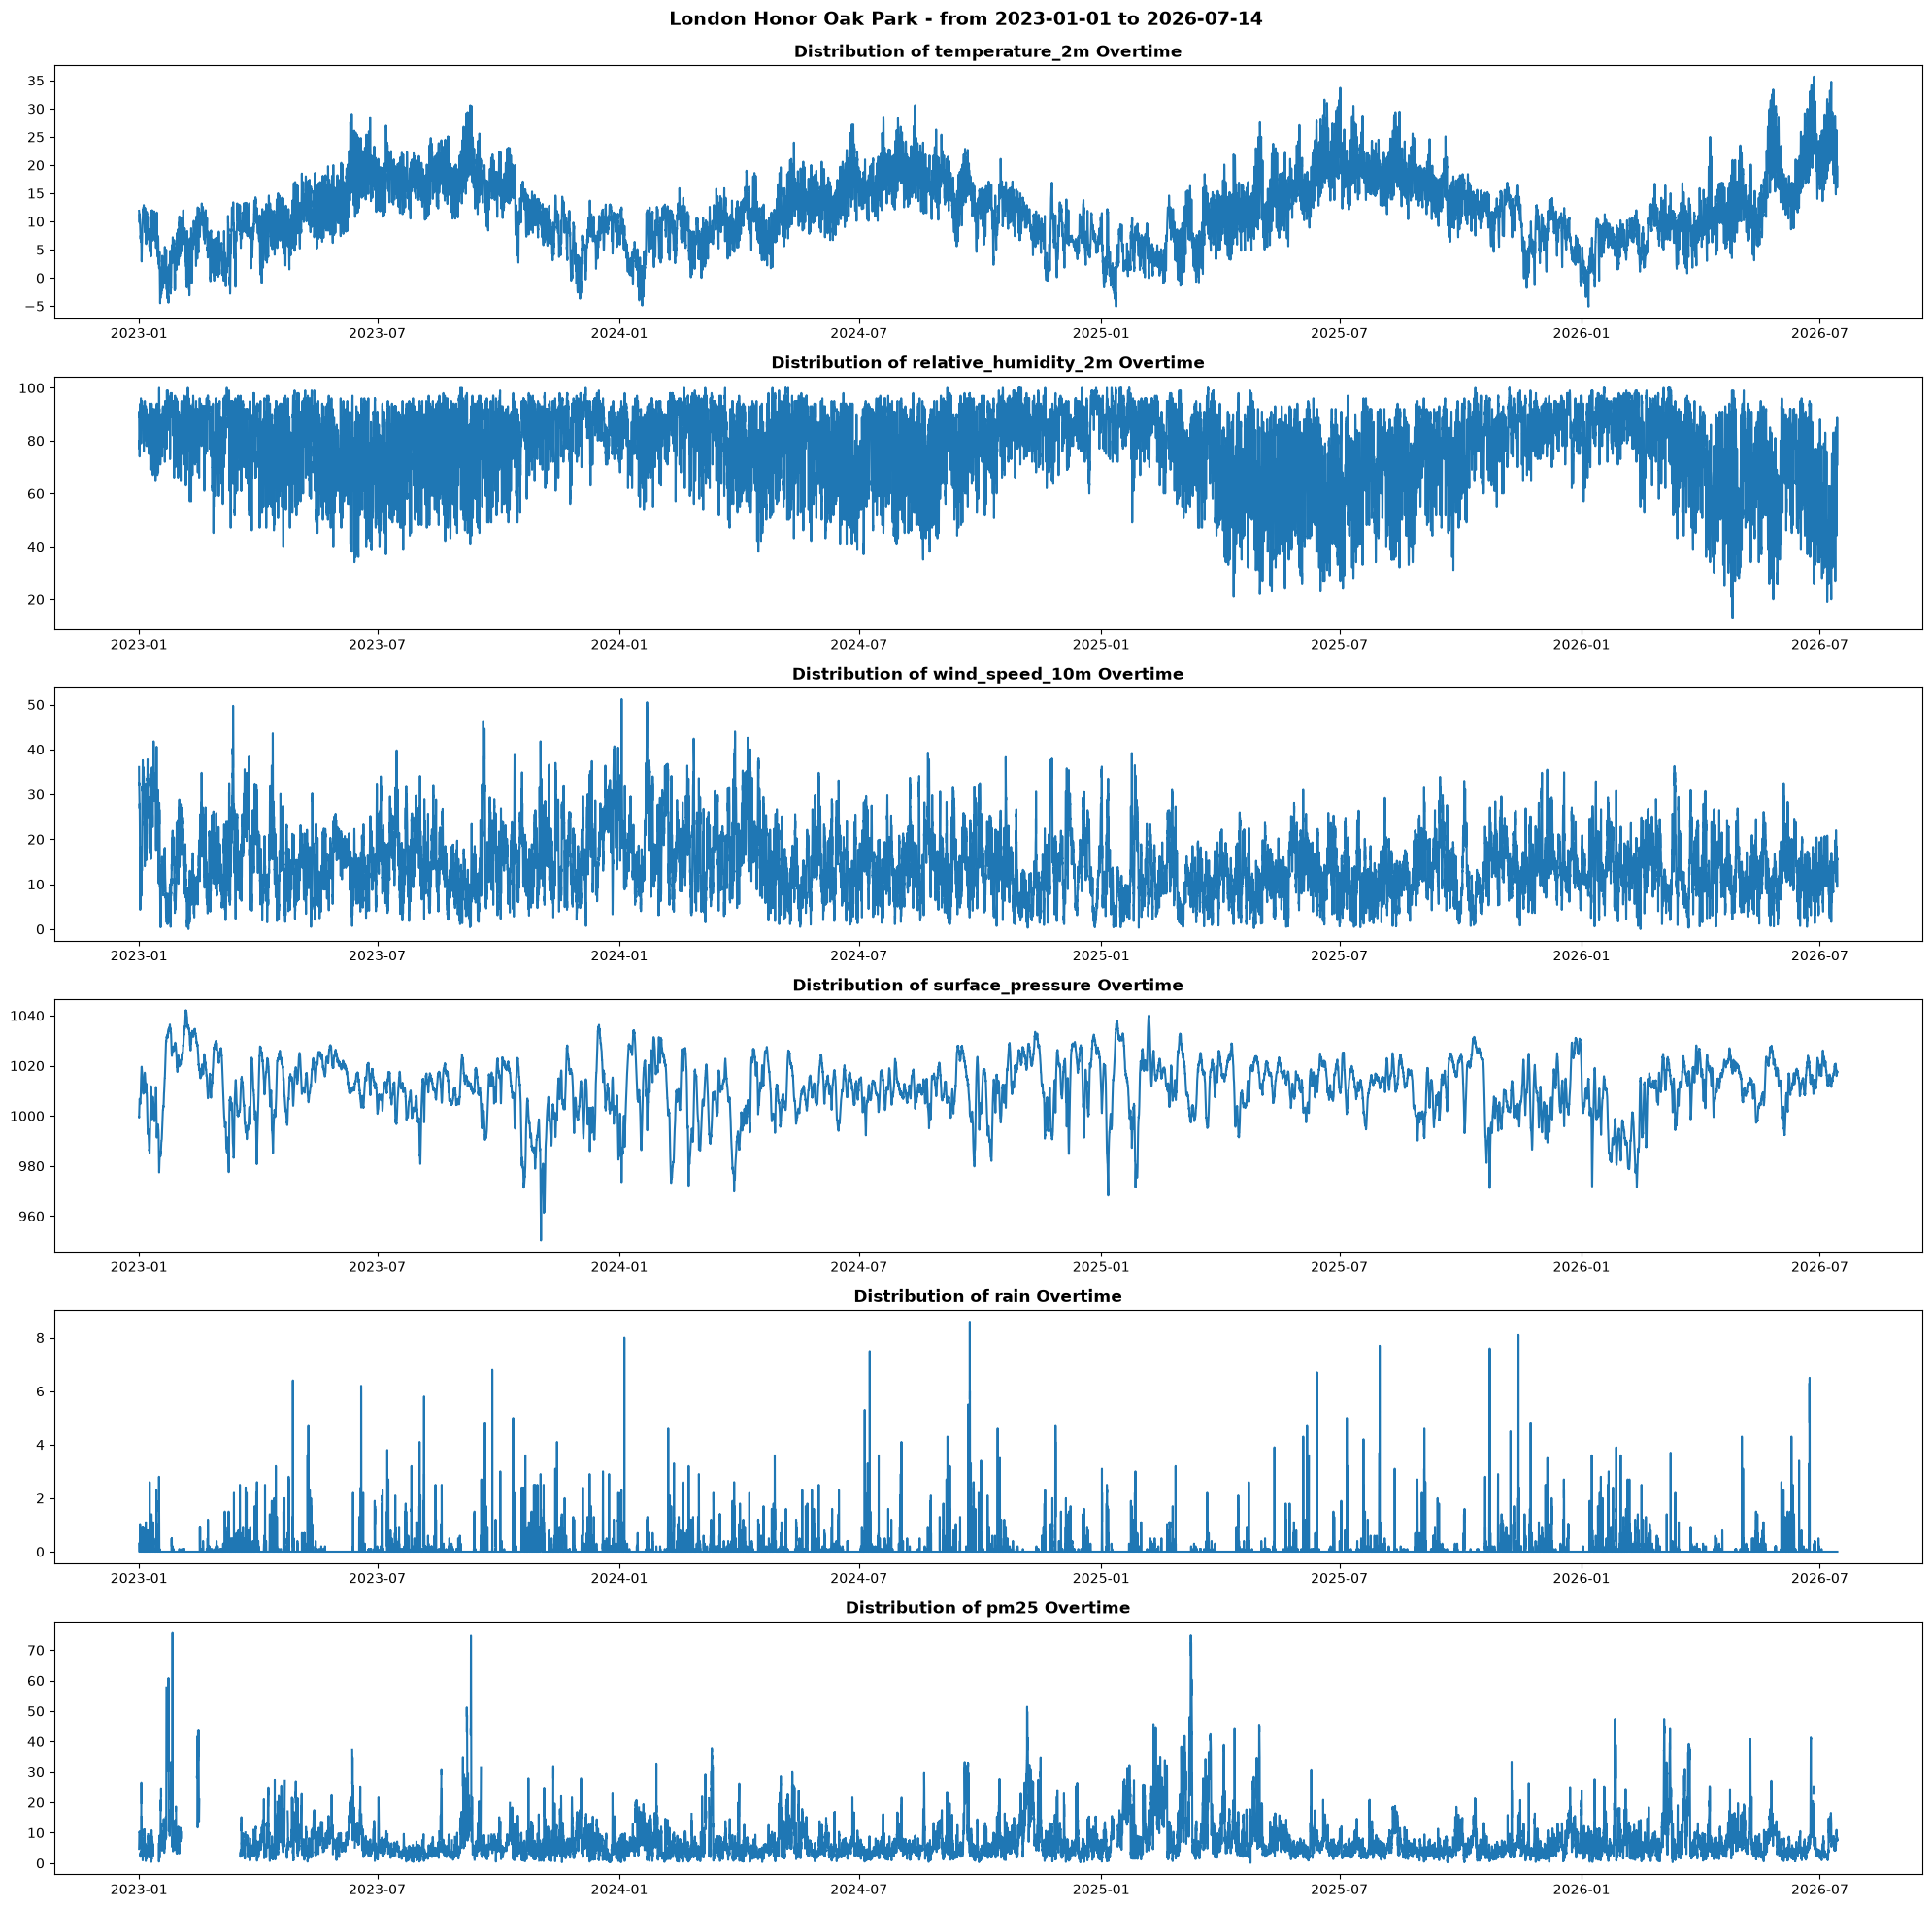

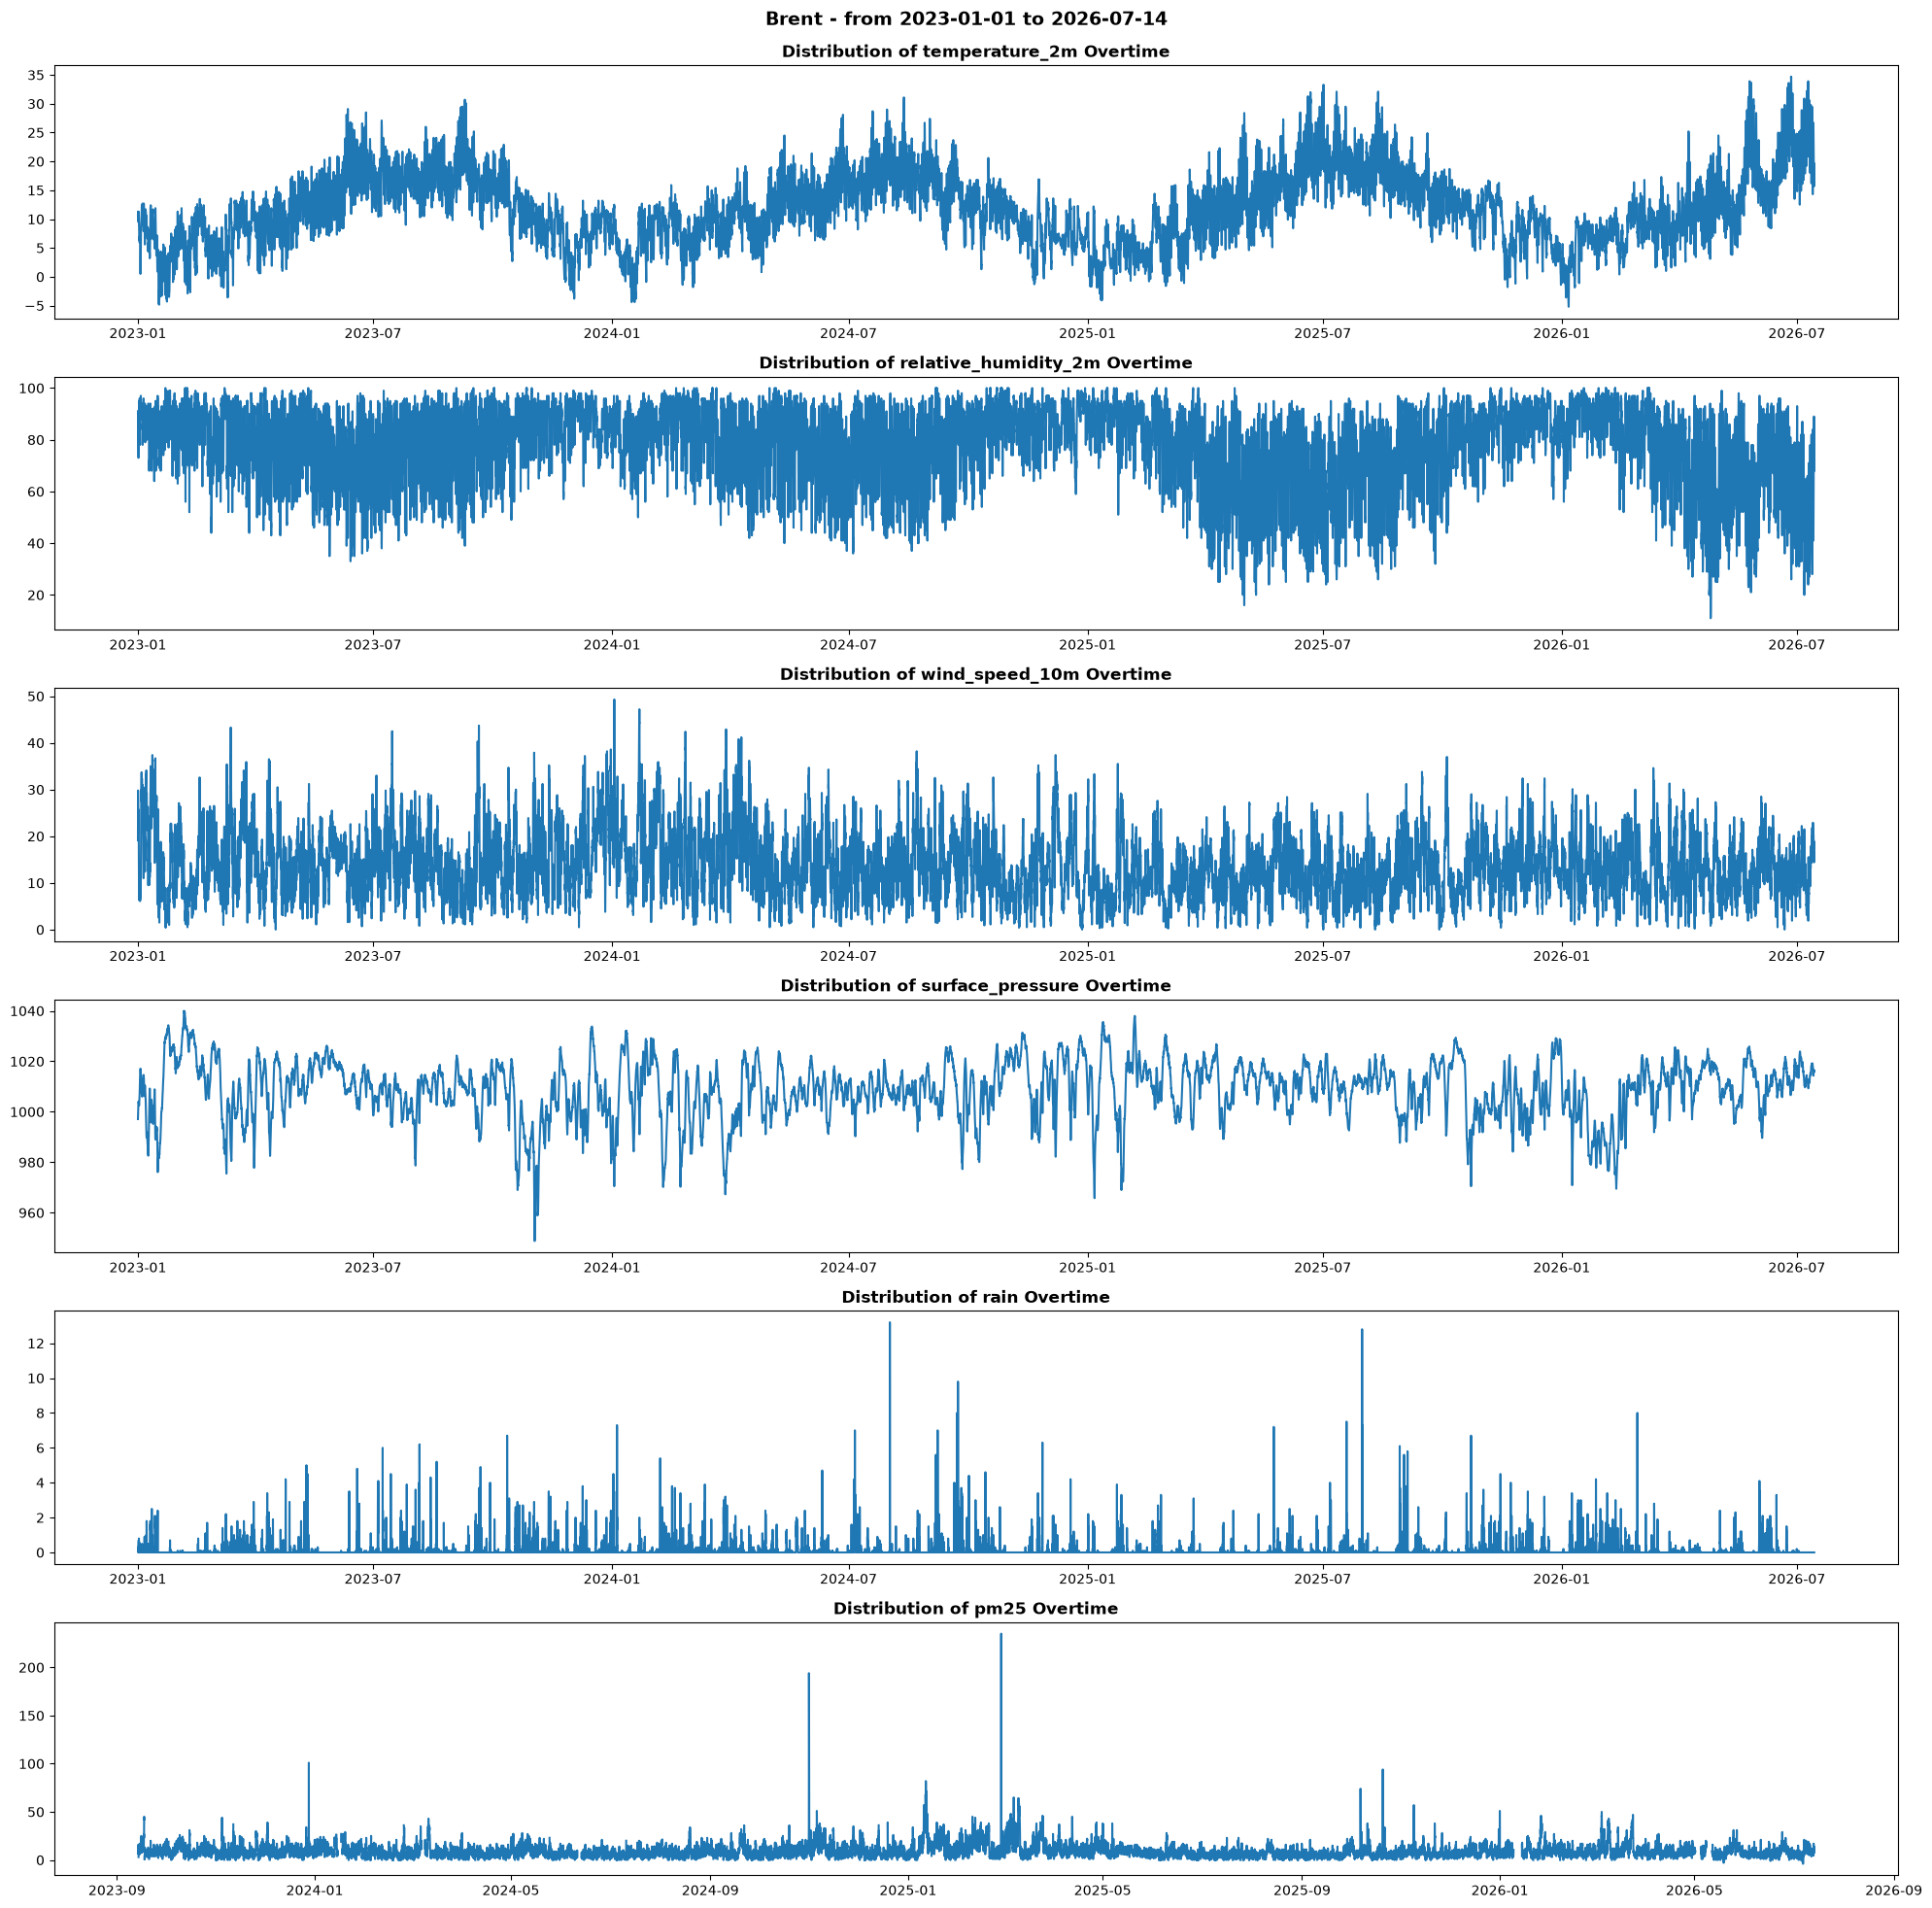

In [13]:
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df.select_dtypes(include='number').columns if col not in forbid]
time_min = df['time_reading'].min().strftime('%Y-%m-%d')
time_max = df['time_reading'].max().strftime('%Y-%m-%d')

stations = df['station_name'].unique()
for station in stations:
    df_temp = df[df['station_name']==station]
    plt.figure(figsize=(20, 20))
    for i, col in enumerate(cols):
        plt.subplot(len(cols), 1, i+1)
        plt.plot(df_temp['time_reading'], df_temp[col])
        plt.title(f'Distribution of {col} Overtime', fontsize=12, fontweight='bold')
    plt.suptitle(f'{station} - from {time_min} to {time_max}\n', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# **Pre-Processing**
---
---

In [14]:
df_prepped = df.copy()

## **1. Handling Missing Values**
---
Source: https://www.epa.gov/outdoor-air-quality-data/about-airdata-reports

In [15]:
stations = df_prepped['station_name'].unique()
for station in stations:
    # Loops through the stations, flags and removes any stations with >= 30% of its values missing
    df_temp = df_prepped[df_prepped['station_name']==station]
    missing_pm25 = df_temp['pm25'].isnull().sum()
    pct_missing = (missing_pm25/len(df_temp))*100
    print(f'Missing value at {station}: {missing_pm25} - {round(pct_missing, 3)} of {station} records')

    if pct_missing>=30:
        print(f'Removing {station} records because its records are >=30% missing')
        df_prepped = df_prepped[df_prepped['station_name'] != station]
        df_prepped.reset_index(inplace=True, drop=True)        

    print(' ')

print(f'Length before removal: {len(df_prepped)}')

# Removing certain days, where 25% or more of its hours does not have a pm25 reading
daily_nan_pct = df_prepped.groupby(by=['station_id', pd.Grouper(key='time_reading', freq='D')])['pm25'].apply(lambda x: x.isna().sum()/24) # getting number of missing hours for each day for each station
valid_days = daily_nan_pct[daily_nan_pct<=0.25].index

df_prepped = df_prepped.set_index(['station_id', df_prepped['time_reading'].dt.floor('D')], drop=False).loc[valid_days].reset_index(drop=True)

print(f'Length after removal: {len(df_prepped)}')

Missing value at Waterloo Place: 5649 - 18.24 of Waterloo Place records
 
Missing value at London Westminster: 9678 - 31.25 of London Westminster records
Removing London Westminster records because its records are >=30% missing
 
Missing value at Camden Kerbside: 8242 - 26.613 of Camden Kerbside records
 
Missing value at Tower Hamlets: 20220 - 65.289 of Tower Hamlets records
Removing Tower Hamlets records because its records are >=30% missing
 
Missing value at Greenwich: 5678 - 18.334 of Greenwich records
 
Missing value at London Honor Oak Park: 2105 - 6.797 of London Honor Oak Park records
 
Missing value at Brent: 7136 - 23.042 of Brent records
 
Length before removal: 154849
Length after removal: 126390


In [16]:
# interpolation - done for each specific station
stations = df_prepped['station_name'].unique()
list_prepped = []
for station in stations:
    df_temp = df_prepped[df_prepped['station_name']==station]
    #df_temp = df_temp.set_index('time_reading', drop=False)
    df_temp['pm25'] = df_temp['pm25'].interpolate(method='polynomial', order=2)
    df_temp = df_temp.reset_index(drop=True)

    list_prepped.append(df_temp)
    print(f'Processed {station}')

df_prepped = pd.concat(list_prepped, axis=0, ignore_index=True)
display(df_prepped.isnull().sum())

Processed Camden Kerbside
Processed Brent
Processed Greenwich
Processed London Honor Oak Park
Processed Waterloo Place


weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    5
longitude               0
latitude                0
dtype: int64

In [17]:
df_prepped

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
0,W235_2023010100,235,152,Camden Kerbside,2023-01-01 00:00:00,11.9,91.0,34.0,995.2,0.8,7.0,-0.175269,51.544210
1,W235_2023010101,235,152,Camden Kerbside,2023-01-01 01:00:00,10.9,92.0,19.4,995.4,0.2,7.0,-0.175269,51.544210
2,W235_2023010102,235,152,Camden Kerbside,2023-01-01 02:00:00,11.6,88.0,29.3,996.0,0.9,7.0,-0.175269,51.544210
3,W235_2023010103,235,152,Camden Kerbside,2023-01-01 03:00:00,10.9,82.0,31.9,996.9,0.0,7.0,-0.175269,51.544210
4,W235_2023010104,235,152,Camden Kerbside,2023-01-01 04:00:00,10.2,80.0,30.7,998.0,0.0,8.0,-0.175269,51.544210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126385,W1561901_2026071405,1561901,270693,Waterloo Place,2026-07-14 05:00:00,16.0,89.0,11.3,1017.2,0.0,8.5,-0.133068,51.507582
126386,W1561901_2026071406,1561901,270693,Waterloo Place,2026-07-14 06:00:00,16.6,87.0,15.8,1017.1,0.0,8.9,-0.133068,51.507582
126387,W1561901_2026071407,1561901,270693,Waterloo Place,2026-07-14 07:00:00,17.0,87.0,15.2,1017.3,0.0,9.8,-0.133068,51.507582
126388,W1561901_2026071408,1561901,270693,Waterloo Place,2026-07-14 08:00:00,18.0,80.0,15.6,1017.4,0.0,10.4,-0.133068,51.507582


## **2. Handling Outliers**
---

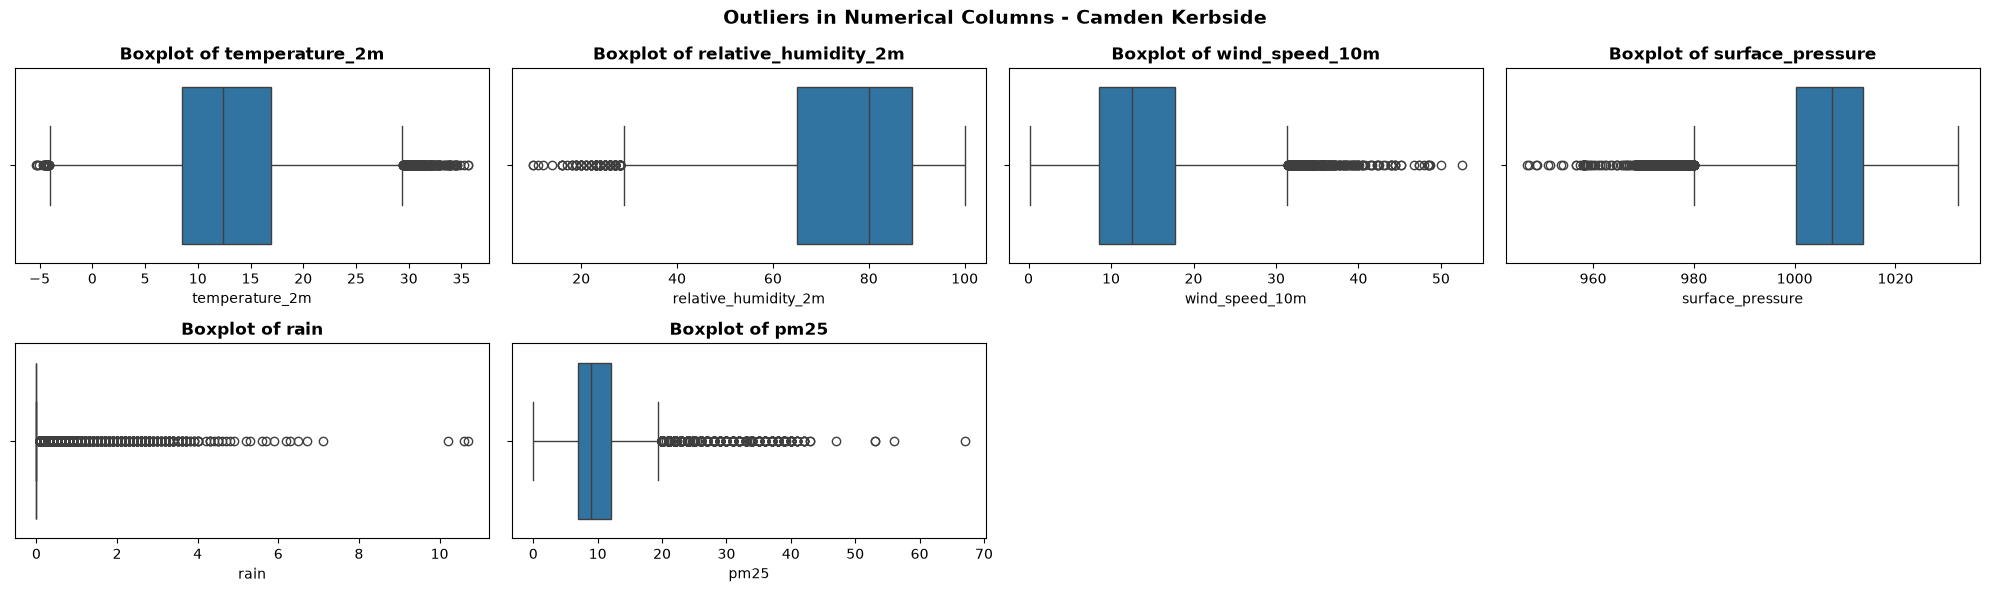

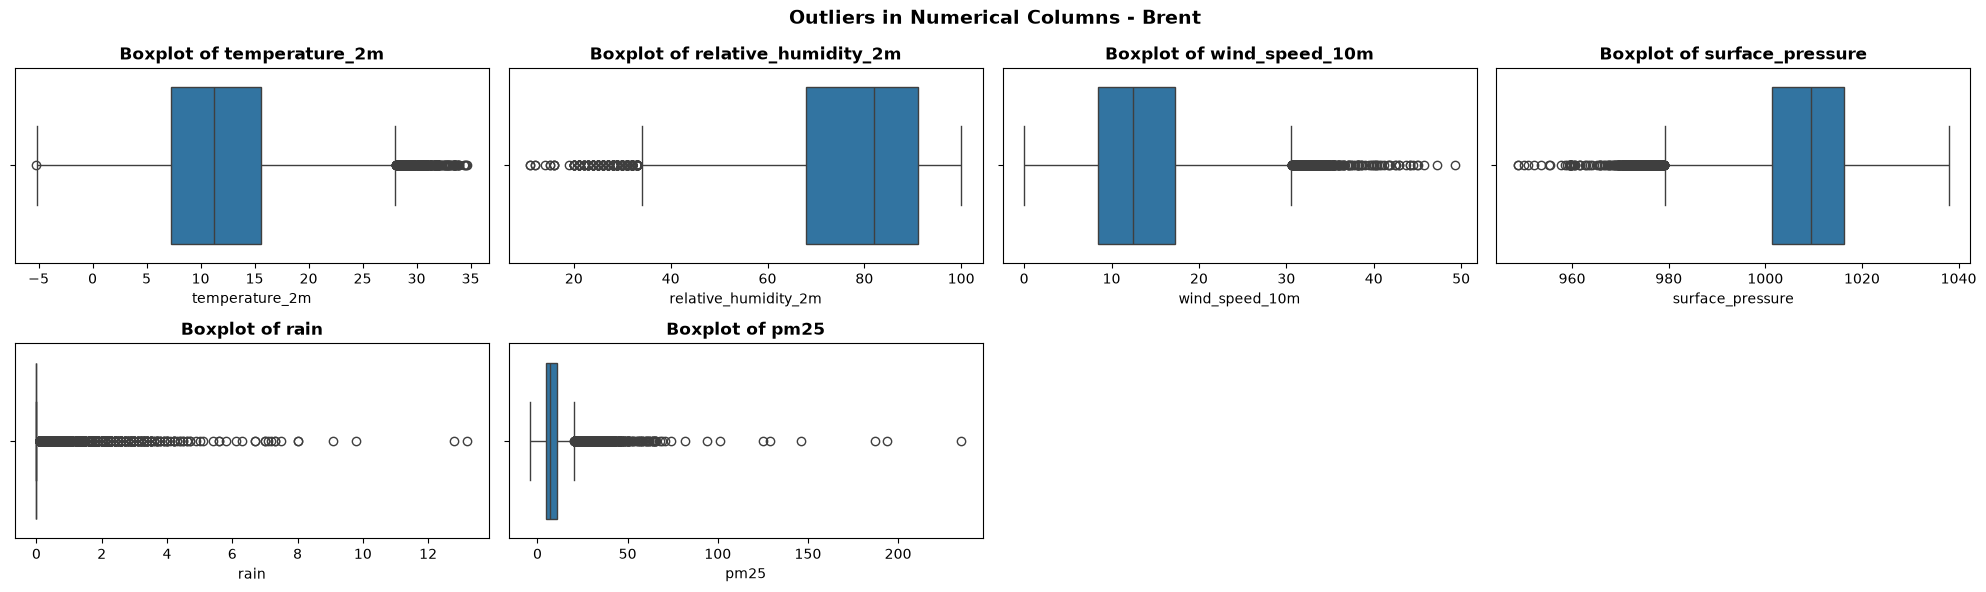

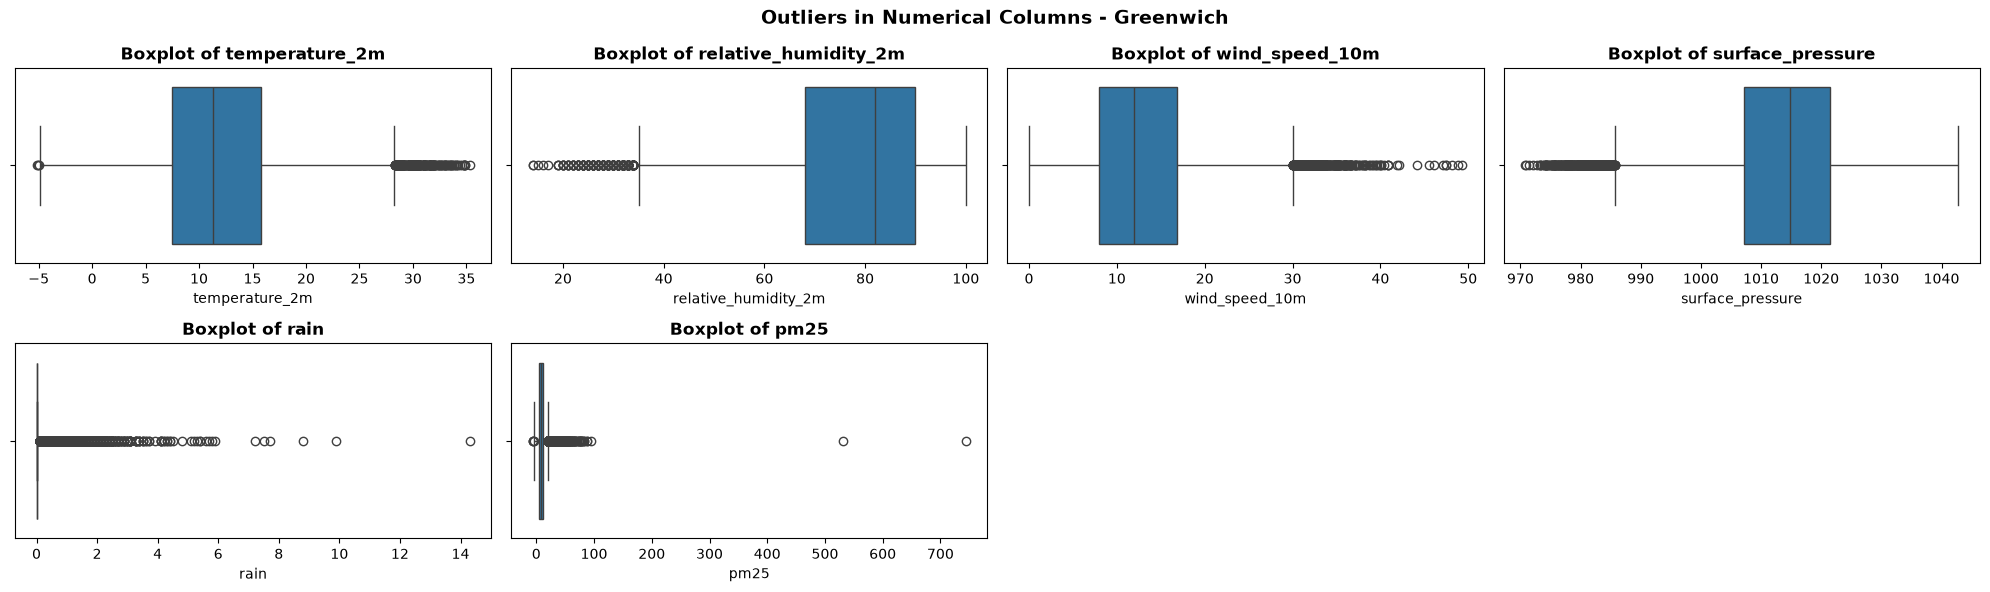

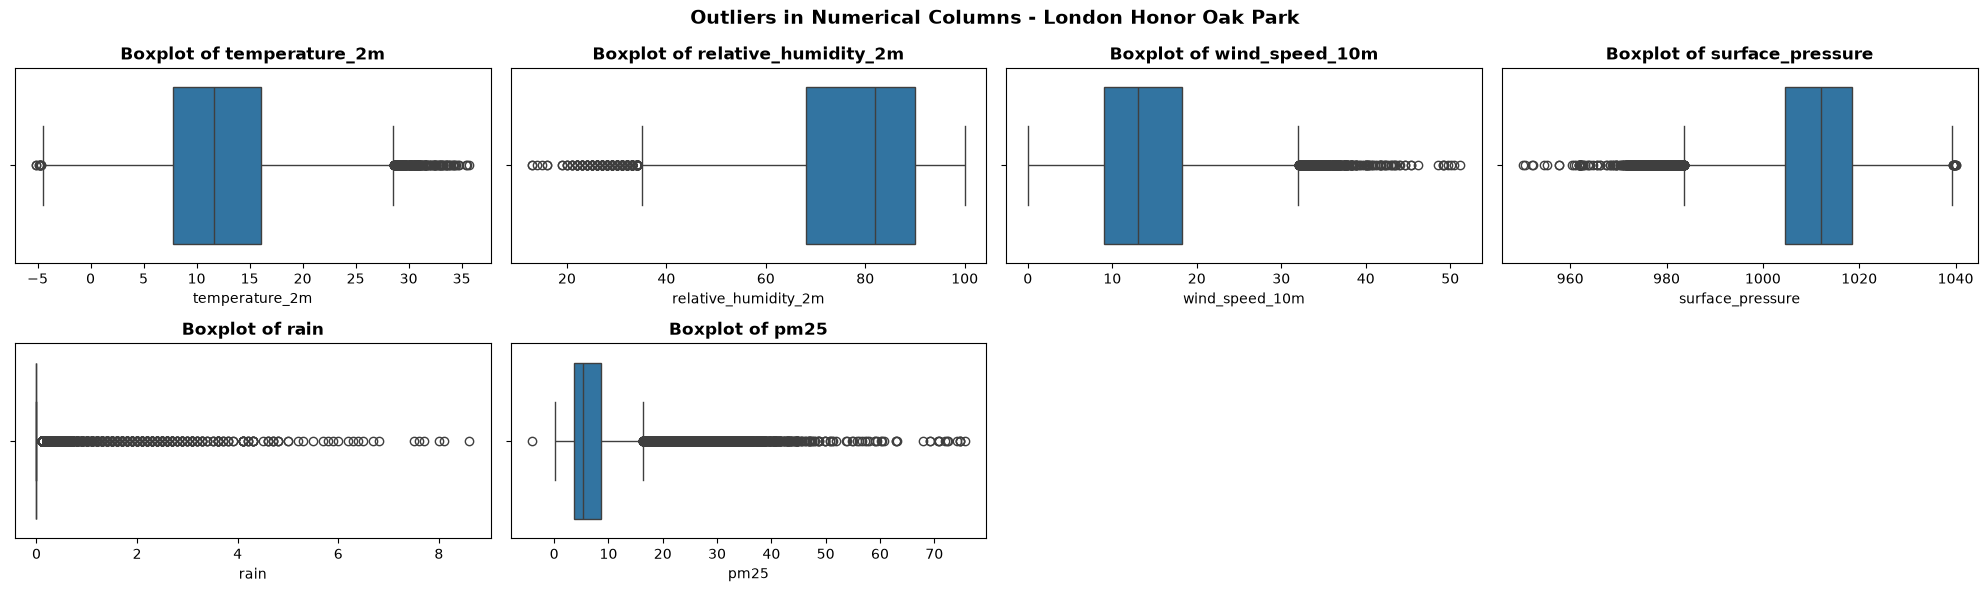

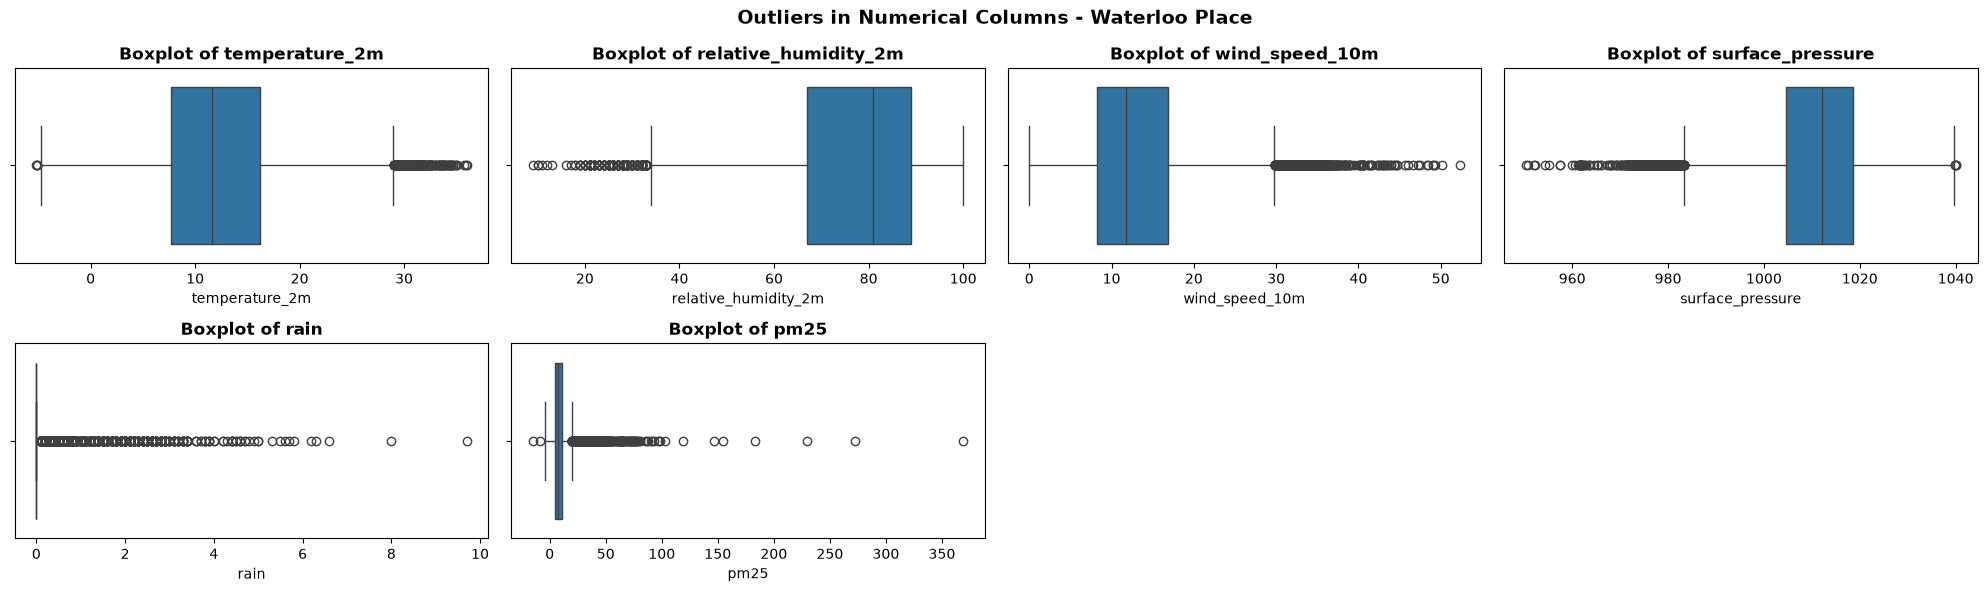

In [18]:
forbid = ['sensor_id', 'station_id', 'longitude', 'latitude']
cols = [col for col in df_prepped.select_dtypes(include='number').columns if col not in forbid]

for station in df_prepped['station_name'].unique():
    temp = df_prepped[df_prepped['station_name']==station]
    plt.figure(figsize=(20, 6))
    for i, col in enumerate(cols):
        plt.subplot(2, 4, i+1)
        sns.boxplot(x=temp[col])
        plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.suptitle(f'Outliers in Numerical Columns - {station}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(' ')

In [19]:
q1 = df_prepped['pm25'].quantile(0.25)
q3 = df_prepped['pm25'].quantile(0.75)
iqr=q3-q1

df_outliers = df_prepped[(df_prepped['pm25'] < (q1-1.5*iqr)) | (df_prepped['pm25'] > (q3+1.5*iqr))]
display(df_outliers)

# As the numbers of outliers are very high, only extreme, impossible values are removed
df_prepped.loc[df_prepped['pm25']>=100] = None

stations = df_prepped['station_name'].unique()
list_prepped = []
for station in stations:
    df_temp = df_prepped[df_prepped['station_name']==station]
    #df_temp = df_temp.set_index('time_reading', drop=False)
    df_temp['pm25'] = df_temp['pm25'].interpolate(method='polynomial', order=3)
    df_temp = df_temp.reset_index(drop=True)

    list_prepped.append(df_temp)
    print(f'Processed {station}')

df_prepped = pd.concat(list_prepped, axis=0, ignore_index=True)
display(df_prepped.isnull().sum())

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude
236,W235_2023011720,235,152,Camden Kerbside,2023-01-17 20:00:00,-2.4,88.0,11.3,984.4,0.0,21.0,-0.175269,51.544210
237,W235_2023011721,235,152,Camden Kerbside,2023-01-17 21:00:00,-2.7,89.0,9.6,984.9,0.0,22.0,-0.175269,51.544210
238,W235_2023011722,235,152,Camden Kerbside,2023-01-17 22:00:00,-3.1,90.0,9.0,985.0,0.0,23.0,-0.175269,51.544210
239,W235_2023011723,235,152,Camden Kerbside,2023-01-17 23:00:00,-3.5,91.0,10.0,985.4,0.0,23.0,-0.175269,51.544210
240,W235_2023011800,235,152,Camden Kerbside,2023-01-18 00:00:00,-3.5,90.0,10.9,986.0,0.0,24.0,-0.175269,51.544210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125974,W1561901_2026062602,1561901,270693,Waterloo Place,2026-06-26 02:00:00,24.7,74.0,10.3,1009.6,0.0,25.9,-0.133068,51.507582
125975,W1561901_2026062603,1561901,270693,Waterloo Place,2026-06-26 03:00:00,25.8,69.0,9.0,1009.6,0.0,26.4,-0.133068,51.507582
125976,W1561901_2026062604,1561901,270693,Waterloo Place,2026-06-26 04:00:00,25.7,69.0,6.7,1008.6,0.0,26.3,-0.133068,51.507582
125977,W1561901_2026062605,1561901,270693,Waterloo Place,2026-06-26 05:00:00,25.4,69.0,6.0,1008.5,0.0,27.7,-0.133068,51.507582


Processed Camden Kerbside
Processed Brent
Processed nan
Processed Greenwich
Processed London Honor Oak Park
Processed Waterloo Place


weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    5
longitude               0
latitude                0
dtype: int64

In [20]:
df_prepped['pm25'] = df_prepped['pm25'].ffill()
df_prepped.isnull().sum()

weather_id              0
sensor_id               0
station_id              0
station_name            0
time_reading            0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
rain                    0
pm25                    0
longitude               0
latitude                0
dtype: int64

## **4. Creating Horizon Features**
---

In [21]:
def create_horizons(num_horizon: int, target: str, df_input):
    list_horizons = []
    for h in range(1, num_horizon+1):
        horizon_name = f'{h}_hours_ahead'
        df_input[horizon_name] = df_input[target].shift(-h)
        list_horizons.append(horizon_name)
    return df_input, list_horizons

def melt_df(df_input, list_horizons: list, base_id_feature: list):
    new_df = pd.melt(
        df_input,
        id_vars=base_id_feature,
        value_vars=list_horizons,
        var_name='horizon',
        value_name='actual_pm25'
    )

    new_df['horizon'] = new_df['horizon'].apply(lambda x: int(x.split('_')[0]))
    new_df.dropna(inplace=True)
    new_df = new_df.sort_values(by=['station_id', 'time_reading', 'horizon']).reset_index(drop=True)
    return new_df

In [22]:
stations = df_prepped['station_name'].unique()
list_prepped = []
for station in stations:
    df_temp = df_prepped[df_prepped['station_name']==station]
    df_temp_n, list_horizons = create_horizons(3, 'pm25', df_temp.copy())
    df_temp_nn = melt_df(df_temp_n, list_horizons, [col for col in df_temp.columns])
    list_prepped.append(df_temp_nn)

df_prepped = pd.concat(list_prepped, axis=0, ignore_index=True)

In [23]:
df_prepped

,weather_id,sensor_id,station_id,station_name,time_reading,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,rain,pm25,longitude,latitude,horizon,actual_pm25
0,W235_2023010100,235.0,152.0,Camden Kerbside,2023-01-01 00:00:00,11.9,91.0,34.0,995.2,0.8,7.0,-0.175269,51.544210,1,7.0
1,W235_2023010100,235.0,152.0,Camden Kerbside,2023-01-01 00:00:00,11.9,91.0,34.0,995.2,0.8,7.0,-0.175269,51.544210,2,7.0
2,W235_2023010100,235.0,152.0,Camden Kerbside,2023-01-01 00:00:00,11.9,91.0,34.0,995.2,0.8,7.0,-0.175269,51.544210,3,7.0
3,W235_2023010101,235.0,152.0,Camden Kerbside,2023-01-01 01:00:00,10.9,92.0,19.4,995.4,0.2,7.0,-0.175269,51.544210,1,7.0
4,W235_2023010101,235.0,152.0,Camden Kerbside,2023-01-01 01:00:00,10.9,92.0,19.4,995.4,0.2,7.0,-0.175269,51.544210,2,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379084,W1561901_2026071406,1561901.0,270693.0,Waterloo Place,2026-07-14 06:00:00,16.6,87.0,15.8,1017.1,0.0,8.9,-0.133068,51.507582,2,10.4
379085,W1561901_2026071406,1561901.0,270693.0,Waterloo Place,2026-07-14 06:00:00,16.6,87.0,15.8,1017.1,0.0,8.9,-0.133068,51.507582,3,10.4
379086,W1561901_2026071407,1561901.0,270693.0,Waterloo Place,2026-07-14 07:00:00,17.0,87.0,15.2,1017.3,0.0,9.8,-0.133068,51.507582,1,10.4
379087,W1561901_2026071407,1561901.0,270693.0,Waterloo Place,2026-07-14 07:00:00,17.0,87.0,15.2,1017.3,0.0,9.8,-0.133068,51.507582,2,10.4


## **5. Station Name Encoding**
---

In [24]:
def apply_encoding(x):
    if x=='Camden Kerbside':
        return 1
    elif x=='Greenwich':
        return 2
    elif x=='London Honor Oak Park':
        return 3
    elif x=='Waterloo Place':
        return 4
    elif x=='Brent':
        return 5
    
df_prepped['station_id'] = df_prepped['station_name'].apply(apply_encoding)

## **5. Data Splitting**
---

In [25]:
def get_train_val_test_slice(df_input, station):
    df_temp = df_input[df_input['station_name'] == station].copy()
    time_dt = list(df_temp['time_reading'].unique())
    train_temp = int(len(time_dt)*0.7) # 70% of data goes to train
    val_temp = int(len(time_dt)*0.1) # 10% of data goes to validation, the last 20% goes to test

    train_dt = time_dt[:train_temp]
    val_dt = time_dt[train_temp:(train_temp+val_temp)]
    test_dt = time_dt[(train_temp+val_temp):]

    print(f'Station {station}:\nTrain: {(len(train_dt))}, Val: {len(val_dt)}, Test: {len(test_dt)}')

    train = df_temp.loc[df_temp['time_reading'].isin(train_dt)]
    val = df_temp.loc[df_temp['time_reading'].isin(val_dt)]
    test = df_temp.loc[df_temp['time_reading'].isin(test_dt)]
    return train, val, test

In [26]:
forbid = ['weather_id', 'sensor_id', 'longitude', 'latitude']
df_prepped = df_prepped[[col for col in df_prepped.columns if col not in forbid]]

In [27]:
stations = df_prepped['station_name'].unique()
list_train = []
list_val = []
list_test = []
for station in stations:
    train, val, test = get_train_val_test_slice(df_prepped, station)
    train=train.drop(columns=['time_reading', 'station_name'])
    val=val.drop(columns=['time_reading', 'station_name'])
    test=test.drop(columns=['time_reading', 'station_name'])

    list_train.append(train)
    list_val.append(val)
    list_test.append(test)

train = pd.concat(list_train, axis=0, ignore_index=True)
val = pd.concat(list_val, axis=0, ignore_index=True)
test = pd.concat(list_test, axis=0, ignore_index=True)

Station Camden Kerbside:
Train: 15858, Val: 2265, Test: 4532
Station Brent:
Train: 16912, Val: 2416, Test: 4832
Station Greenwich:
Train: 17426, Val: 2489, Test: 4980
Station London Honor Oak Park:
Train: 20451, Val: 2921, Test: 5845
Station Waterloo Place:
Train: 17808, Val: 2544, Test: 5089


In [28]:
x_cols_cat = ['station_id', 'horizon']
x_cols_num = [col for col in train.columns if col!='actual_pm25' and col not in x_cols_cat]
y_col = ['actual_pm25']
print(f'Independent variables: {x_cols_num} + {x_cols_cat}\nTarget variable: {y_col}')

Independent variables: ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'rain', 'pm25'] + ['station_id', 'horizon']
Target variable: ['actual_pm25']


## **6. Data Scaling**
---

In [29]:
def fit_scalers(data_input):
    scalers_dict = {}
    forbid = ['station_id', 'horizon']
    cols = [col for col in data_input.select_dtypes(include='number').columns if col not in forbid]

    for station in data_input['station_id'].unique():
        scalers_dict[int(station)] = {}
        data_temp = data_input[data_input['station_id']==station]
        #display(data_temp)
        for col in cols:
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaler.fit(data_temp[col].values.reshape(-1, 1))
            scalers_dict[station][col] = scaler
    
    return scalers_dict, cols

def scale_dataframe(data_input, scalers, cols):
    data_input = data_input.copy()
    results = []

    for station in data_input['station_id'].unique():
        data_temp = data_input[data_input['station_id']==station]
        for col in cols:
            scaler = scalers[station][col]
            data_temp[col] = scaler.transform(data_temp[col].values.reshape(-1, 1))
        results.append(data_temp)

    df_result = pd.concat(results, axis=0, ignore_index=True)
    return df_result


In [30]:
scalers_dict, cols_scaled = fit_scalers(df_prepped)

train_scaled = scale_dataframe(train, scalers_dict, cols_scaled)
val_scaled = scale_dataframe(val, scalers_dict, cols_scaled)
test_scaled = scale_dataframe(test, scalers_dict, cols_scaled)

In [147]:
functions_path = os.path.join(os.getcwd(), os.path.abspath('functions/scalers'))
if not os.path.exists(functions_path):
    os.makedirs(functions_path)

for station, scalers in scalers_dict.items():
    path_station = os.path.join(functions_path, str(station))
    if not os.path.exists(path_station):
        os.makedirs(path_station)
    
    for col, scaler in scalers.items():
        joblib.dump(scaler, os.path.join(path_station, f'{col}_scaler.joblib'))

# **Modelling**
---
---

## **1. Function Definition**
---

In [104]:
# Class for Generating Window Sizes
class time_series_dataset(Dataset):
    def __init__(self, df_input, cols_ind_num: list, cols_ind_cat: list, cols_target: list, window_size: int=10):
        self.window_size = window_size # setting window size, which is x rows used to predict an nth PM 2.5 readings
        self.predictor_num=cols_ind_num # the numerical, scaled time-series input
        self.predictor_cat=cols_ind_cat # the categorical encoded feature
        self.target=cols_target # target feature

        self.groups = []
        # This loop loops through all station id and horizon combinations, getting the dataframe for each combination and placing it 
        # into the self.groups list to ensure that each batch's windows only consists of one horizon and station id
        for _, temp in df_input.groupby(by=['station_id', 'horizon'], sort=False):
            group = temp.reset_index(drop=True)
            if len(group)>window_size:
                self.groups.append(group)

        self.idx_map = []
        # This loop creates an index map, where each item contains a dataframe (each having unique combination of station id and horizon)
        # and in every loop iteration, it creates a tuple consisting of the dataframe's index inside the self.groups list and the index
        # for each record of the dataframe
        for i, item in enumerate(self.groups):
            n_valid = len(item)-window_size 
            for local_idx in range(n_valid): # loops through every valid index of the dataframe
                self.idx_map.append((i, local_idx))
    
    def __len__(self):
        return len(self.idx_map)

    def __getitem__(self, idx: int):
        id_group, id_df = self.idx_map[idx]
        curr_df = self.groups[id_group]

        # This function extracts the n-th and the next 10 rows of the dataframe as well as the next record after said 10
        # rows (as the target). This is done for every batch (which is set to 32, explained further below)
        predictors_num = curr_df[self.predictor_num][id_df:id_df + self.window_size].values.reshape(-1, len(self.predictor_num)).copy()
        predictors_cat = curr_df[self.predictor_cat][id_df:id_df + self.window_size].values.reshape(-1, len(self.predictor_cat)).copy()
        target = curr_df[self.target][id_df + self.window_size:id_df + self.window_size + 1].values.reshape(-1, 1).copy()

        return {
            'numerical_inputs': torch.FloatTensor(predictors_num), # numerical inputs converted to torch tensor (essentially numpy ndarray but for deep learning)
            'categorical_inputs': torch.tensor(predictors_cat, dtype=torch.int64), # categorical, encoded inputs
            'target': torch.FloatTensor(target) # target feature
        }

# function for Streaming Inputs Into the Model
def generator_inputs_target(df_input, cols_ind_num: list, cols_ind_cat: list, cols_target: list , shuffle:bool=True, window_size: int=10, batch_size: int=32):
    # The seed_worker function below is used to set a seed for each worker involved in shuffling and streaming the data
    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    g_func = torch.Generator() # sets the seed for the torch library's data processing
    g_func.manual_seed(SEED)

    data = time_series_dataset(df_input, cols_ind_num, cols_ind_cat, cols_target, window_size=window_size) # creates the dataframe object
    loader = DataLoader(            # The dataloader here does the shuffling and batching for the time series dataset. If batch is set to 32,
        data,                       # and when the window is set to say 10, each batch will have 32 sets of arrays (each array has 10 records)
        batch_size=batch_size,      # which is fed into the deep learning model to train said model to learn the patterns of those ten steps
        shuffle=shuffle,            # make prediction on the target
        pin_memory=False,
        #num_workers=6,
        worker_init_fn=seed_worker, # utilizing the worker function to set the seed
        drop_last=True, # drops the last batch, since it likely does not have the same size
        generator=g_func # utilizing the generator function to set the seed
    )

    for input_ in loader:
        # This loop streams the outputs from dataloader, extracting the categorical and numerical features, as well as the target feature, and 
        # would stream each batch (when created) into the deep learning model later (in a format compatible with tensorflow which is as numpy
        # multi-dimension array)
        features = {
            'numerical_inputs': input_['numerical_inputs'].detach().numpy(), 
            'categorical_inputs': input_['categorical_inputs'].detach().numpy()
        }
        target = input_['target'].detach().numpy().squeeze(axis=1)
        yield features, target

## **2. Input/Output Set Up**
---

In [105]:
window_size = 20 # lower windows seem to do worse
batch_size = 32

output_signature = (
    {
        'numerical_inputs': tf.TensorSpec(shape=(batch_size, window_size, len(x_cols_num)), dtype=tf.float32),
        'categorical_inputs': tf.TensorSpec(shape=(batch_size, window_size, len(x_cols_cat)), dtype=tf.int32)
    },
    tf.TensorSpec(shape=(batch_size, 1), dtype=tf.float32)
)

train_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(train_scaled, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

val_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(val_scaled, shuffle=False, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

test_stream = tf.data.Dataset.from_generator(
    generator=lambda: generator_inputs_target(test_scaled, shuffle=False, cols_ind_num=x_cols_num, cols_ind_cat=x_cols_cat, cols_target=y_col, window_size=window_size, batch_size=batch_size),
    output_signature=output_signature
)

train_dataset = train_stream.repeat().prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_stream.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_stream.prefetch(buffer_size=tf.data.AUTOTUNE)

## **3. Model Architecture and Training**
---

In [168]:
models_dir = os.path.join(os.getcwd(), 'models')
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

best_checkpoint_path = os.path.join(models_dir, 'lstm_best.keras')
path_logs_training = os.path.join(models_dir, 'training_logs_lstm.csv')
path_per_epoch_log = os.path.join(models_dir, 'model_backup')
if not os.path.exists(path_per_epoch_log):
    os.makedirs(path_per_epoch_log)

# Checkpoint Callbacks
csv_logging = tf.keras.callbacks.CSVLogger(
    filename=path_logs_training, append=True
)
per_epoch_log = tf.keras.callbacks.BackupAndRestore(
    backup_dir=path_per_epoch_log, save_freq='epoch', delete_checkpoint=True
)
best_cp_log = tf.keras.callbacks.ModelCheckpoint(
    filepath=best_checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=False, save_freq='epoch'
)

# Training Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, verbose=1, min_delta=1e-4, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', patience=2, verbose=1, min_lr=1e-6, min_delta=1e-4, factor=0.2
)

In [169]:
# Numerical input layer
num_input = tf.keras.Input(shape=(window_size, len(x_cols_num)), name='numerical_inputs')

# Categorical input layer 
cat_input = tf.keras.Input(shape=(window_size, len(x_cols_cat)), name='categorical_inputs')

# Horizon layer
horizon_scalar = tf.keras.layers.Lambda(lambda x: x[:, 0, 1])(cat_input)
station_scalar = tf.keras.layers.Lambda(lambda x: x[:, 0, 0])(cat_input)
horizon_layer = tf.keras.layers.Flatten()(tf.keras.layers.Embedding(input_dim=4, output_dim=2)(horizon_scalar))

# Station id layer
station_scalar = tf.keras.layers.Lambda(lambda x: x[:, 0, 0])(cat_input)
station_layer = tf.keras.layers.Flatten()(tf.keras.layers.Embedding(input_dim=6, output_dim=4)(station_scalar)) 
# note: only use reshape to flatten the array of values and preserve sequential pattern (Flatten is used when preserving such patterns is not needed)

static_features = tf.keras.layers.Concatenate()([horizon_layer, station_layer])

# Numerical layer
layer_model = tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='swish')(num_input) # used to capture pattern from sequential data
layer_model = tf.keras.layers.LSTM(128, dropout=0.3, recurrent_dropout=0.2, return_sequences=True)(layer_model)
layer_model = tf.keras.layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2, return_sequences=True)(layer_model)
layer_model = tf.keras.layers.Attention()([layer_model, layer_model])
layer_model = tf.keras.layers.GlobalAveragePooling1D()(layer_model)

# Output layers
combined_output = tf.keras.layers.Concatenate()([layer_model, static_features])
layer_out = tf.keras.layers.Dense(32, activation='swish')(combined_output)
layer_out = tf.keras.layers.BatchNormalization()(layer_out) # normalizes values returned by the Dense layer
layer_out = tf.keras.layers.Dropout(0.3)(layer_out)
model_out = tf.keras.layers.Dense(1)(layer_out)

model = tf.keras.models.Model(inputs=[num_input, cat_input], outputs=model_out)
model.compile(optimizer='adam', loss='mae', metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanSquaredError()]) # compiling & setting model metrics

In [170]:
def get_steps_compute(data_obj, batch_size):
    return len(data_obj) // batch_size

train_obj = time_series_dataset(train_scaled, x_cols_num, x_cols_cat, y_col, window_size)
val_obj = time_series_dataset(val_scaled, x_cols_num, x_cols_cat, y_col, window_size)
test_obj = time_series_dataset(test_scaled, x_cols_num, x_cols_cat, y_col, window_size)

steps_train = get_steps_compute(train_obj, batch_size)
steps_val = get_steps_compute(val_obj, batch_size)
steps_test = get_steps_compute(test_obj, batch_size)
print(f'Length of train steps: {steps_train}\nLength of validation steps: {steps_val}\nLength of test steps: {steps_test}')

Length of train steps: 8283
Length of validation steps: 1175
Length of test steps: 2359


In [171]:
fit = model.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=40,
    callbacks=[csv_logging, per_epoch_log, best_cp_log, early_stop, reduce_lr],
    verbose=1,
)

Epoch 1/40


c:\Users\user\works\DE_studies\openmeteo_ml\ne_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


8283/8283 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0383 - mean_squared_error: 0.0040 - root_mean_squared_error: 0.0629
Epoch 1: val_loss improved from None to 0.02091, saving model to c:\Users\user\works\DE_studies\openmeteo_ml\models\lstm_best.keras

Epoch 1: finished saving model to c:\Users\user\works\DE_studies\openmeteo_ml\models\lstm_best.keras
8283/8283 ━━━━━━━━━━━━━━━━━━━━ 604s 72ms/step - loss: 0.0383 - mean_squared_error: 0.0040 - root_mean_squared_error: 0.0629 - val_loss: 0.0209 - val_mean_squared_error: 0.0013 - val_root_mean_squared_error: 0.0356 - learning_rate: 0.0010
Epoch 2/40
8283/8283 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0295 - mean_squared_error: 0.0020 - root_mean_squared_error: 0.0452
Epoch 2: val_loss did not improve from 0.02091
8283/8283 ━━━━━━━━━━━━━━━━━━━━ 590s 71ms/step - loss: 0.0295 - mean_squared_error: 0.0020 - root_mean_squared_error: 0.0452 - val_loss: 0.0213 - val_mean_squared_error: 0.0012 - val_root_mean_squared_error: 0.0352 - learning_r

## **4. Evaluation**
---

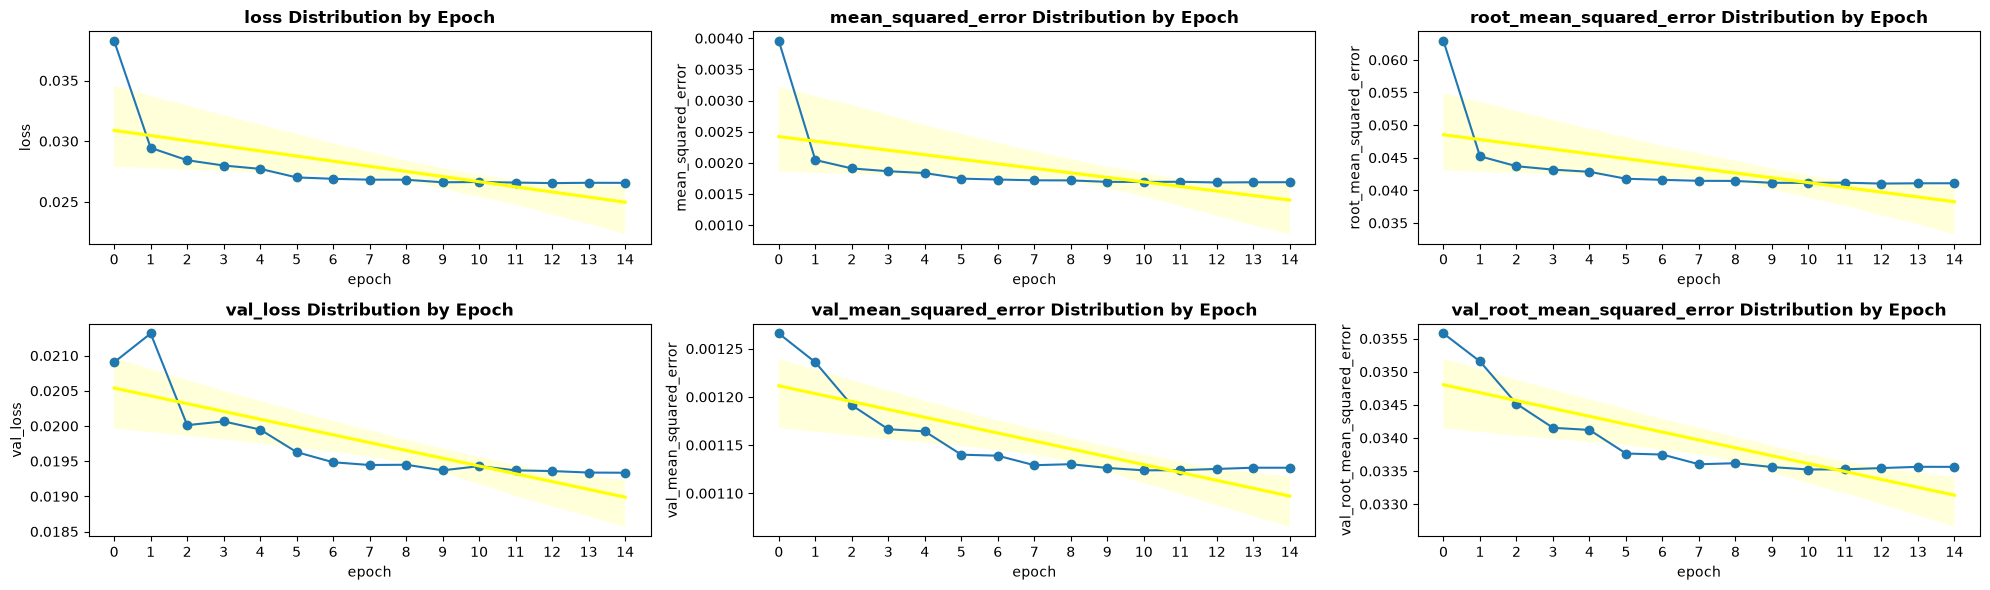

In [172]:
logs = pd.read_csv(path_logs_training)

plt.figure(figsize=(20, 6))
for i, col in enumerate([c for c in logs.columns if c!='epoch']):
    plt.subplot(2, 3, i+1)
    plt.plot(logs['epoch'], logs[col], marker='o')
    sns.regplot(x=logs['epoch'], y=logs[col], color='yellow', order=1)
    plt.title(f'{col} Distribution by Epoch', fontsize=12, fontweight='bold')
    if len(logs)<=20:
        plt.xticks(list(logs['epoch'].values))
plt.tight_layout()
plt.show()

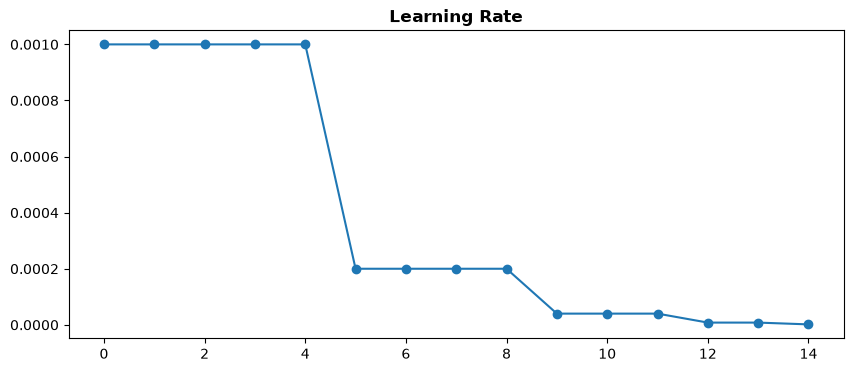

In [173]:
# Learning Rate
plt.figure(figsize=(10, 4))
plt.plot(logs['epoch'], fit.history['learning_rate'], marker='o')
plt.title('Learning Rate', fontsize=12, fontweight='bold')
plt.show()

In [167]:
path = os.path.abspath('./models/lstm_best_v1.keras')
model_n = tf.keras.models.load_model(path, safe_mode=False)

In [177]:
next(iter(test_dataset)) # for testing & previewing the dataset values/outputs
list_targets = []
list_preds = []

for feature, target in test_dataset:
    target_n = target.numpy()
    cat = feature['categorical_inputs'].numpy()

    pred = model_n.predict(feature)
    for batch in range(len(cat)):
        list_cat = []
        for i in range(len(cat[batch])):
            if list_cat is None or int(cat[batch][i][0]) not in list_cat:
                list_cat.append(int(cat[batch][i][0]))
        
        #print(f'Batch {batch} - categories: {set(list_cat)}')

        if len(list_cat)==1:
            scaler = scalers_dict[list_cat[0]]['actual_pm25']
        else:
            print('There is more than 1 category, skipping...\n')
            continue
        
        list_targets.append(scaler.inverse_transform([target_n[batch]])[0][0])
        list_preds.append(scaler.inverse_transform([pred[batch]])[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

In [178]:
rmse = root_mean_squared_error(list_targets, list_preds)
mae = mean_absolute_error(list_targets, list_preds)
mse = mean_squared_error(list_targets, list_preds)
smape = SymmetricMeanAbsolutePercentageError()
smape = smape(torch.tensor(list_targets), torch.tensor(list_preds))
print(f'RMSE: {rmse}\nMAE: {mae}\nMSE: {mse}\nsMAPE: {smape}')

RMSE: 3.5207163346162007
MAE: 2.251485562881163
MSE: 12.395443508833337
sMAPE: 0.2732822597026825


In [179]:
test_results = model.evaluate(test_dataset, steps=steps_test)
#print(f"Test result: {test_results}")
#res_target = scalers_dict.inverse_transform(np.array([test_results]).reshape(-1, 1))

res_dict = {
    'mae': float(test_results[0]),
    'mse': float(test_results[1]),
    'rmse': float(test_results[2])
}
res_dict

2359/2359 ━━━━━━━━━━━━━━━━━━━━ 143s 61ms/step - loss: 0.0244 - mean_squared_error: 0.0014 - root_mean_squared_error: 0.0378


{'mae': 0.02435562200844288,
 'mse': 0.03784095495939255,
 'rmse': 0.0014319377951323986}